# 🏎️ Análisis Experimental de Neuroevolución en Python

Este cuaderno permite monitorear y analizar el comportamiento del ensamble de Redes Neuronales a lo largo de las variadas generaciones que el simulador F1 ha estado ejecutando.

Recordatorio Experimental:
- Cada iteración enfrenta una **pista aleatoria fractal**. Se definieron **100 Seeds exclusivas (del 0 al 99)** para forzar que la IA generalice su trazado sobre chicanas y rectas diversas. Cualquier evaluación final que superé la generación 100 operará sobre un torneo ajeno.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Estilo general de gráficos
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Importación del Archivo de Telemetría Dispersa (`training_log.csv`)
El simulador escribe métricas convencionales y adicionalmente serializa el **fenotipo absoluto** (los pesos completos de las matrices de conexión de la Red Neuronal ganadora de esa iteración) en formato JSON anidado (`weights_json`).

In [22]:
df = pd.DataFrame()
try:
    df = pd.read_csv('training_log.csv')
    # Convertimos los pesos JSON (texto no estructurado) en Estructuras Nativas Numéricas (Listas Python)
    df['weights'] = df['weights_json'].apply(lambda w: json.loads(w) if pd.notnull(w) else [])
    display(df[['generation', 'best_fitness', 'avg_progress', 'seed']].tail(5))
except Exception as e:
    print(f"El archivo no está disponible todavía o está vacío: {e}")

,generation,best_fitness,avg_progress,seed
858,859,394.37,270.37,59
859,860,388.74,244.20,60
860,861,431.51,338.10,61
861,862,23.00,19.83,62
862,863,454.49,80.73,63


## 2. Convergencia Heurística de la Aptitud Promedio y Global
Analizaremos si los vehículos genéticos sobreviven con mayor persistencia al paso del tiempo o si el Ruido Gaussiano detona saltos de aptitud en las generaciones estancadas.

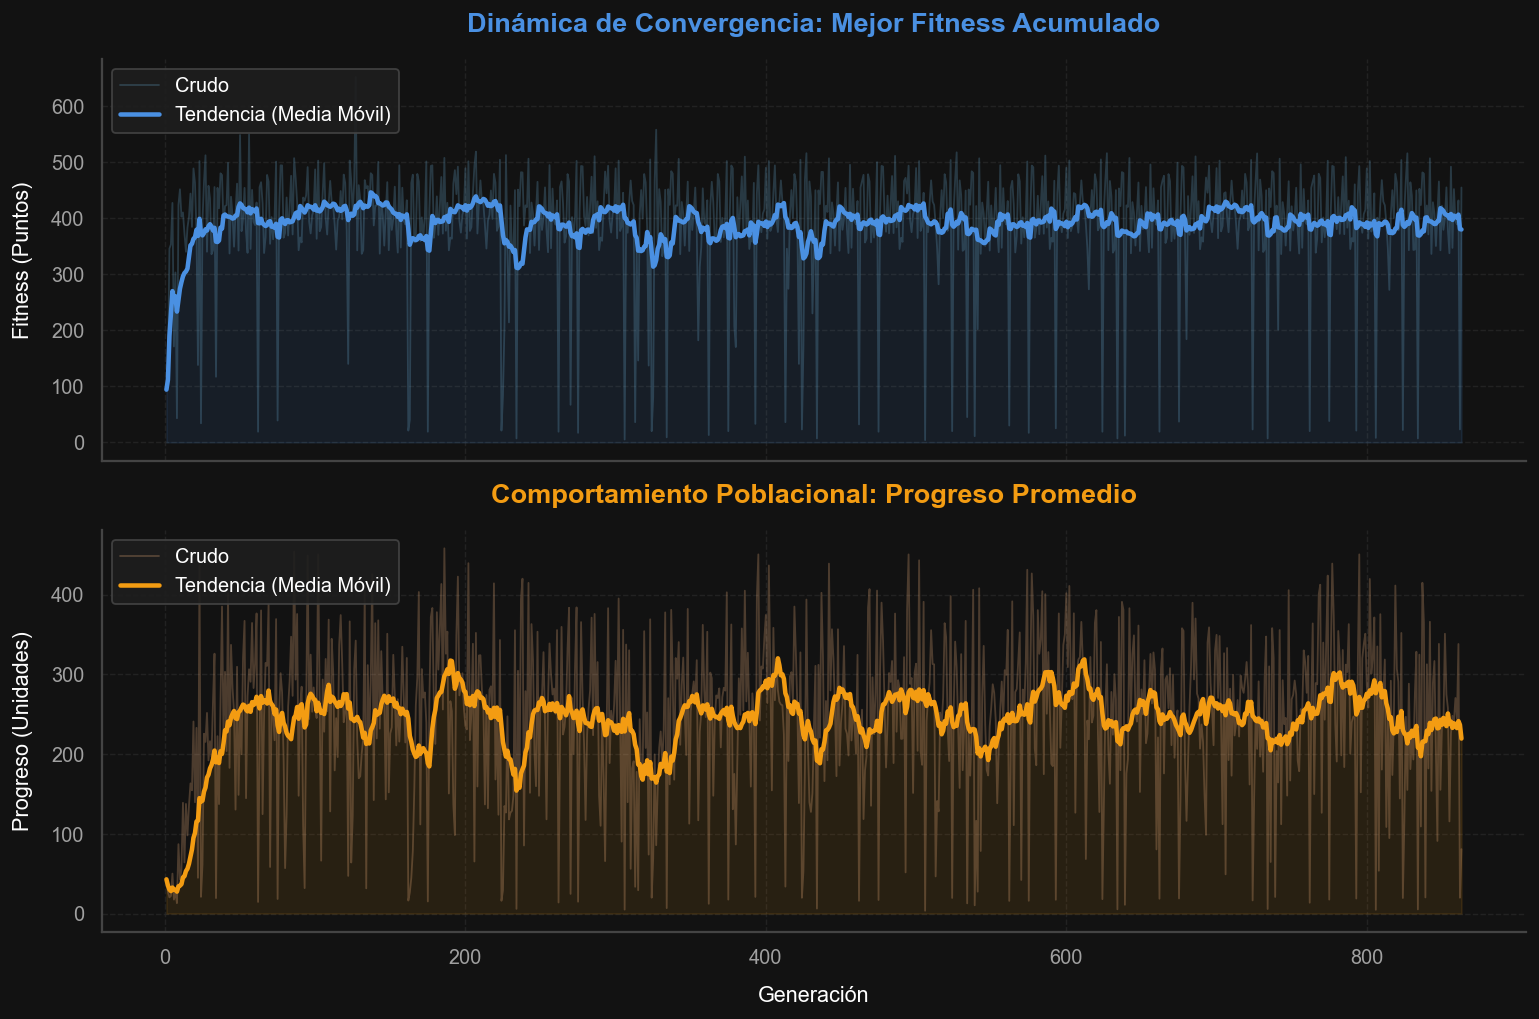

In [23]:
# 2. Calcular la media móvil (Mejora: min_periods=1 evita que la línea empiece cortada)
window_size = 15
df['best_fitness_trend'] = df['best_fitness'].rolling(window=window_size, min_periods=1).mean()
df['avg_progress_trend'] = df['avg_progress'].rolling(window=window_size, min_periods=1).mean()

# 3. Configuración estética premium (Modo Oscuro Data Science)
plt.style.use('dark_background') 
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
fig.patch.set_facecolor('#121212') # Fondo general sólido

# Función auxiliar para estilizar ejes y no repetir código
def style_axis(ax, title, ylabel, color):
    ax.set_facecolor('#121212')
    ax.set_title(title, fontsize=15, pad=15, color=color, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, color='white', labelpad=10)
    # Cuadrícula sutil y punteada
    ax.grid(True, color='#2a2a2a', linestyle='--', linewidth=0.8, alpha=0.7)
    # Ocultar bordes superior y derecho (Mejora visual clave)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')
    ax.tick_params(colors='#a0a0a0')

# --- GRÁFICA 1: BEST FITNESS (ax1) ---
# Datos crudos
ax1.plot(df['generation'], df['best_fitness'], color='#6baed6', alpha=0.25, label='Crudo', linewidth=1)
# Línea de tendencia
ax1.plot(df['generation'], df['best_fitness_trend'], color='#4a90e2', linewidth=2.5, label='Tendencia (Media Móvil)')
# Mejora: Relleno suave bajo la curva de tendencia
ax1.fill_between(df['generation'], df['best_fitness_trend'], color='#4a90e2', alpha=0.1)

style_axis(ax1, 'Dinámica de Convergencia: Mejor Fitness Acumulado', 'Fitness (Puntos)', '#4a90e2')
ax1.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='#444444', labelcolor='white', framealpha=0.9)

# --- GRÁFICA 2: AVG PROGRESS (ax2) ---
# Datos crudos
ax2.plot(df['generation'], df['avg_progress'], color='#fdbb84', alpha=0.25, label='Crudo', linewidth=1)
# Línea de tendencia
ax2.plot(df['generation'], df['avg_progress_trend'], color='#f39c12', linewidth=2.5, label='Tendencia (Media Móvil)')
# Mejora: Relleno suave bajo la curva de tendencia
ax2.fill_between(df['generation'], df['avg_progress_trend'], color='#f39c12', alpha=0.1)

style_axis(ax2, 'Comportamiento Poblacional: Progreso Promedio', 'Progreso (Unidades)', '#f39c12')
ax2.set_xlabel('Generación', fontsize=12, color='white', labelpad=10)
ax2.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='#444444', labelcolor='white', framealpha=0.9)

# 4. Ajustar márgenes para que no se superpongan los textos y renderizar
plt.tight_layout()
plt.show()

## 3. Topología de Conexiones de la Red (Análisis de Pesos)
¿Qué aprenden los agentes? Observaremos qué peso sináptico otorga la mejor red entrenada a sus sensores iniciales. Al graficar un mapa de calor, verificaremos si dependen sustancialmente del radar frontal o lateral.

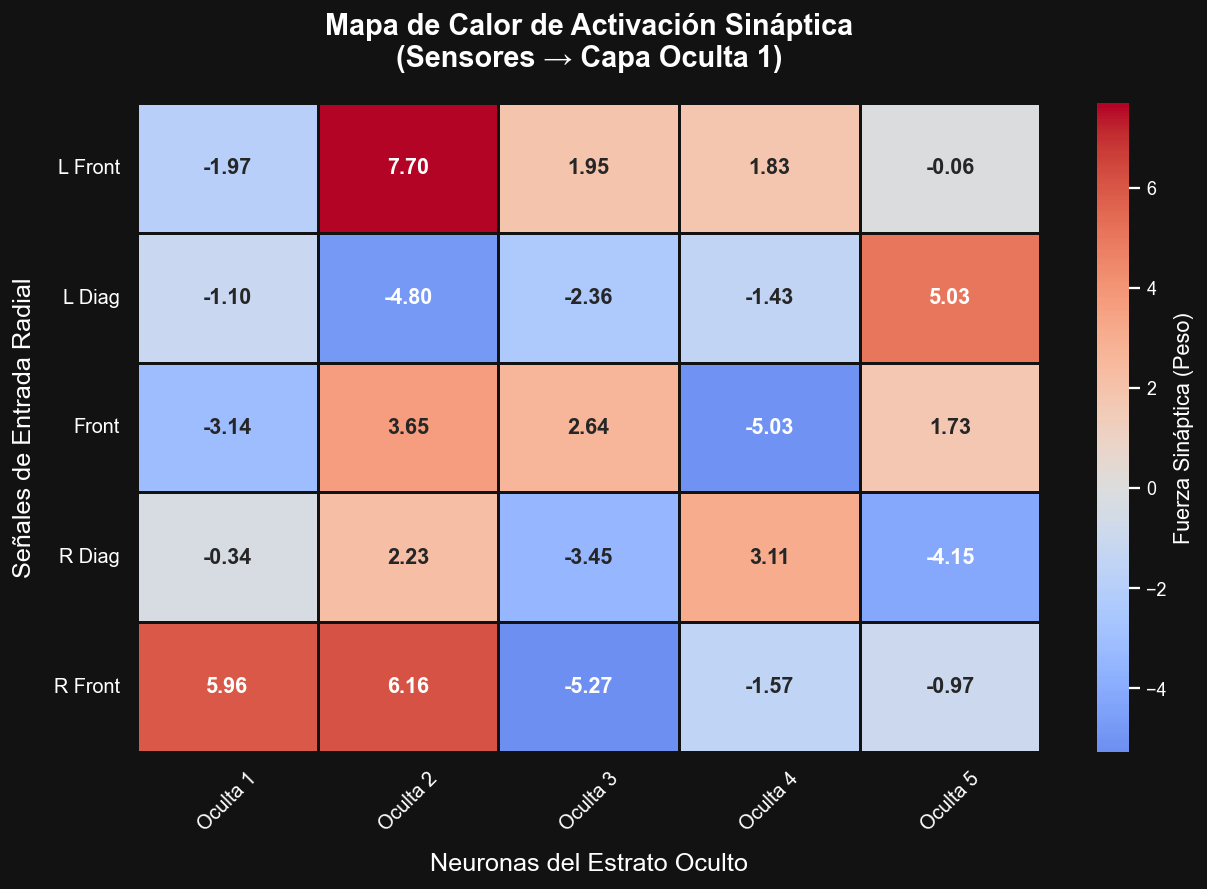

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import io

# 1. Datos
csv_data = """generation,best_fitness,avg_progress,seed,weights_json
1,94.00,42.90,1,"[[[0.668, -0.568, 0.633, -0.539, -0.166], [-0.396, 0.094, -0.414, 0.492, -0.264], [-0.089, 0.401, -0.635, 0.062, -0.673], [0.252, -0.768, 0.659, -0.275, -0.084], [-0.580, -0.211, -0.745, 0.730, 0.033]], [0.0, 0.0, 0.0, 0.0, 0.0]]"
22,138.00,44.87,22,"[[[-1.974624752998352, 7.697175979614258, 1.9527233839035034, 1.829624056816101, -0.056228164583444595], [-1.1003292798995972, -4.8027472496032715, -2.3560917377471924, -1.42952561378479, 5.026456356048584], [-3.139108896255493, 3.652665376663208, 2.6447482109069824, -5.034234523773193, 1.732027530670166], [-0.34183773398399353, 2.231661558151245, -3.4471819400787354, 3.1108076572418213, -4.152295112609863], [5.9578447341918945, 6.162253379821777, -5.271394729614258, -1.5716419219970703, -0.9730379581451416]], [-1.9254430532455444, 6.499515056610107, -3.623772382736206, -2.7257044315338135, -2.668334484100342]]"
"""

df = pd.read_csv(io.StringIO(csv_data))

if not df.empty and 'weights_json' in df.columns:
    raw_weights_str = df.iloc[-1]['weights_json']
    
    try:
        last_top_weights = json.loads(raw_weights_str)
        capa_entrada = np.array(last_top_weights[0])
        
        if capa_entrada.ndim == 2:
            # --- CORRECCIÓN VISUAL DE ALTO CONTRASTE ---
            # Forzamos un estilo oscuro base para Matplotlib
            plt.style.use('dark_background')
            
            # Creamos la figura asignando un fondo sólido (no transparente)
            fig, ax = plt.subplots(figsize=(10, 7))
            fig.patch.set_facecolor('#121212') 
            ax.set_facecolor('#121212')

            # Renderizamos el heatmap con líneas divisorias oscuras para separar colores claros
            sns.heatmap(capa_entrada, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                        linewidths=1.5, linecolor='#121212', 
                        annot_kws={"size": 12, "weight": "bold"}, # Números interiores más claros
                        cbar_kws={"label": "Fuerza Sináptica (Peso)"},
                        xticklabels=[f"Oculta {i+1}" for i in range(capa_entrada.shape[1])],
                        yticklabels=["L Front", "L Diag", "Front", "R Diag", "R Front"],
                        ax=ax)
            
            # Forzamos el color blanco en TODOS los textos y títulos
            plt.title('Mapa de Calor de Activación Sináptica\n(Sensores → Capa Oculta 1)', 
                      pad=20, fontsize=16, color='white', fontweight='bold')
            plt.xlabel('Neuronas del Estrato Oculto', fontsize=14, color='white', labelpad=10)
            plt.ylabel('Señales de Entrada Radial', fontsize=14, color='white', labelpad=10)
            
            # Ajustamos los ticks (los nombres de las filas/columnas)
            plt.xticks(rotation=45, color='white', fontsize=11)
            plt.yticks(rotation=0, color='white', fontsize=11)
            
            # Arreglamos el texto de la barra de color lateral que también se perdía
            cbar = ax.collections[0].colorbar
            cbar.ax.yaxis.label.set_color('white')
            cbar.ax.yaxis.label.set_size(12)
            cbar.ax.tick_params(colors='white', labelsize=10)
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Error: La matriz extraída no es 2D.")

    except json.JSONDecodeError as e:
        print(f"Error al decodificar el JSON: {e}")

---
*Nota de Torneo*: Una vez alcanzadas las **100 seeds originales**, el modelo se saturará a sí mismo y deberá ser puesto a prueba en inferencia directa (`tournament.py`) evaluando un escenario no visto usando validación directa sin mutación.


## 4. Inferencia Dinámica: Explicación de la Neuroevolución
A continuación, vamos a someter a la red campeona a una batería aleatoria de datos. 
Como los 5 sensores de raycast miden la distancia hasta el borde de la pista (normalizada entre 0 y 1), 
podemos simular diferentes escenarios:
- **Coche en muro izquierdo**: Los sensores L Front y L Diag están muy cerca de 0.
- **Pista despejada**: Todos los sensores retornan 1.
- **Coche en muro derecho**: Los sensores Frontales y Derechos bajan a 0.

Observaremos la toma de decisión generada por la Función de Activación Hiperbólica (`tanh`) 
que dicta la aceleración y la orientación del volante basándose estrictamente en las matemáticas matriciales.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
# 2. Función de activación
def tanh(x):
    return np.tanh(x)

# 3. Simulación del Perceptrón (Forward Propagation)
def predict_brain(sensors, weights_list):
    # Tu arquitectura real sí tiene 8 componentes (w0, b0, w1, b1, w2, b2, w3, b3)
    w0, b0 = np.array(weights_list[0]), np.array(weights_list[1])
    w1, b1 = np.array(weights_list[2]), np.array(weights_list[3])
    w2, b2 = np.array(weights_list[4]), np.array(weights_list[5])
    w3, b3 = np.array(weights_list[6]), np.array(weights_list[7])
    
    a1 = tanh(np.dot(sensors, w0) + b0)
    a2 = tanh(np.dot(a1, w1) + b1)
    a3 = tanh(np.dot(a2, w2) + b2)
    out = tanh(np.dot(a3, w3) + b3)
    
    return out  

# 4. Extracción e Inferencia
if not df.empty and 'weights_json' in df.columns:
    
    raw_weights_str = df.iloc[-1]['weights_json']
    
    try:
        last_weights = json.loads(raw_weights_str)
        
        if len(last_weights) == 8:
            
            scenarios = {
                'Muro a la Izquierda': np.array([0.05, 0.1, 0.9, 1.0, 1.0]),
                'Pista Despejada': np.array([1.0, 1.0, 1.0, 1.0, 1.0]),
                'Curva Cerrada Derecha': np.array([1.0, 1.0, 0.3, 0.1, 0.05])
            }
            
            results = []
            for name, data in scenarios.items():
                prediction = predict_brain(data, last_weights)
                results.append({
                    'Escenario': name, 
                    'Volante (Steering)': prediction[0], 
                    'Acelerador (Gas)': prediction[1]
                })
                
            df_pred = pd.DataFrame(results)
            
            # --- RENDERIZADO VISUAL ESTÉTICO ---
            plt.style.use('dark_background')
            fig, ax = plt.subplots(figsize=(10, 5))
            fig.patch.set_facecolor('#121212') 
            ax.set_facecolor('#121212')
            
            df_pred.set_index('Escenario').plot(
                kind='barh', ax=ax, color=['#f39c12', '#4a90e2'], 
                edgecolor='#121212', linewidth=1.5
            )
            
            ax.set_title('Inferencia del Modelo: Respuesta a Estímulos Puros', 
                         pad=15, fontsize=14, fontweight='bold', color='white')
            ax.set_xlim(-1.1, 1.1)
            ax.axvline(0, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
            ax.set_xlabel('Magnitud de Activación (-1 a 1)', fontsize=12, color='white')
            ax.set_ylabel('') 
            
            plt.legend(loc='upper right', facecolor='#2d2d2d', edgecolor='none', labelcolor='white')
            
            plt.tight_layout()
            plt.show()
            
            # --- EXPLICACIÓN AUTOMÁTICA EN CONSOLA ---
            print("\n" + "="*60)
            print("📝 ANÁLISIS DE LA INFERENCIA MATRICIAL:")
            print("="*60)
            for _, row in df_pred.iterrows():
                if row['Volante (Steering)'] > 0.1:
                    desc_volante = f"GIRAR DERECHA (+{row['Volante (Steering)']:.2f})"
                elif row['Volante (Steering)'] < -0.1:
                    desc_volante = f"GIRAR IZQUIERDA ({row['Volante (Steering)']:.2f})"
                else:
                    desc_volante = f"MANTENER CENTRO ({row['Volante (Steering)']:.2f})"
                
                if row['Acelerador (Gas)'] > 0.5:
                    desc_gas = f"ACELERAR A FONDO (+{row['Acelerador (Gas)']:.2f})"
                elif row['Acelerador (Gas)'] > 0:
                    desc_gas = f"ACELERAR SUAVE (+{row['Acelerador (Gas)']:.2f})"
                else:
                    desc_gas = f"FRENAR ({row['Acelerador (Gas)']:.2f})"
                
                print(f"🔹 Escenario: [{row['Escenario'].upper()}]")
                print(f"   ↳ Decisión del Perceptrón : {desc_volante} | {desc_gas}\n")
                
        else:
            print(f"La matriz extraída no tiene la arquitectura esperada (8 capas). Contiene {len(last_weights)}.")
            
    except json.JSONDecodeError as e:
        print(f"Error crítico al decodificar el JSON de pesos: {e}")
else:
    print("El DataFrame df no está cargado o falta la columna 'weights_json'.")

La matriz extraída no tiene la arquitectura esperada (8 capas). Contiene 2.


### 5. Dinámica Interactiva: Propagación Sináptica Frente a Entradas Aleatorias

Para complementar la inferencia de escenarios estáticos, se ha desarrollado un renderizado dinámico que permite observar el flujo de activación neuronal a lo largo de múltiples pasos de simulación. 

En cada iteración temporal, el algoritmo somete a la red a un vector de entrada estocástico (con valores normalizados entre 0 y 1, emulando lecturas de sensores asimétricas) y ejecuta una propagación hacia adelante (*Forward Pass*) a través de la topología multicapa (5 -> 5 -> 3 -> 3 -> 2).

**Interpretación de la Telemetría Visual:**
* **Nodos (Hexágonos):** El gradiente de color refleja la salida de la función de activación tangente hiperbólica (`tanh`). El amarillo indica inhibición profunda (cercano a -1), el gris denota neutralidad (0), y el verde representa excitación máxima (1).
* **Sinapsis (Conexiones):** Las aristas ilustran la matriz de pesos del modelo campeón. Las conexiones verdes transfieren pesos positivos (excitatorios), mientras que las rojas transfieren pesos negativos (inhibitorios). El grosor de cada línea es directamente proporcional al valor absoluto del peso sináptico, permitiendo identificar visualmente las "vías de decisión" primarias de la red.

In [26]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd
import json
from IPython.display import display

# --- 1. CARGA DE DATOS REALES ---
df = pd.read_csv('training_log.csv')
architecture = [5, 5, 3, 3, 2]

if not df.empty and 'weights_json' in df.columns:
    raw_weights_str = df.iloc[-1]['weights_json']
    try:
        weights_to_use = json.loads(raw_weights_str)
        
        if len(weights_to_use) != 8:
            raise ValueError(f"La matriz extraída no tiene la arquitectura esperada (8 capas). Contiene {len(weights_to_use)}.")

        # --- 2. POSICIONES DE LOS NODOS ---
        def get_node_positions(arch):
            pos = {}
            layer_spacing = 1.5
            node_spacing = 1.0
            max_nodes = max(arch)
            
            for l_idx, num_nodes in enumerate(arch):
                x = l_idx * layer_spacing
                y_offset = (max_nodes - num_nodes) * node_spacing / 2.0
                for n_idx in range(num_nodes):
                    y = y_offset + n_idx * node_spacing
                    node_id = f"L{l_idx+1}_N{n_idx+1}"
                    pos[node_id] = (x, y)
            return pos

        node_positions = get_node_positions(architecture)
        node_ids_ordered = list(node_positions.keys())

        # --- 3. EXTRACCIÓN DE SINAPSIS ---
        def get_weighted_edges(arch, w_list):
            edges = []
            w_matrices = [w_list[0], w_list[2], w_list[4], w_list[6]]
            for l_idx in range(len(arch) - 1):
                w_mat = np.array(w_matrices[l_idx])
                for s_idx in range(arch[l_idx]):
                    for d_idx in range(arch[l_idx+1]):
                        src_id = f"L{l_idx+1}_N{s_idx+1}"
                        dst_id = f"L{l_idx+2}_N{d_idx+1}"
                        weight = w_mat[s_idx, d_idx]
                        edges.append((src_id, dst_id, weight))
            return edges

        weighted_edges = get_weighted_edges(architecture, weights_to_use)

        # --- 4. LÓGICA DE INFERENCIA ---
        def tanh(x): return np.tanh(x)

        def forward_pass_all_activations(sensors, w_list):
            w0, b0 = np.array(w_list[0]), np.array(w_list[1])
            w1, b1 = np.array(w_list[2]), np.array(w_list[3])
            w2, b2 = np.array(w_list[4]), np.array(w_list[5])
            w3, b3 = np.array(w_list[6]), np.array(w_list[7])
            
            acts = [sensors]
            a1 = tanh(np.dot(sensors, w0) + b0); acts.append(a1)
            a2 = tanh(np.dot(a1, w1) + b1); acts.append(a2)
            a3 = tanh(np.dot(a2, w2) + b2); acts.append(a3)
            out = tanh(np.dot(a3, w3) + b3); acts.append(out)
            return acts

        num_steps = 10
        all_steps_node_data = []
        for _ in range(num_steps):
            random_input = np.random.uniform(0, 1, architecture[0])
            step_activations = forward_pass_all_activations(random_input, weights_to_use)
            
            node_data_map = {}
            for l_idx, layer_act in enumerate(step_activations):
                for n_idx, act_val in enumerate(layer_act):
                    node_id = f"L{l_idx+1}_N{n_idx+1}"
                    node_data_map[node_id] = act_val
            all_steps_node_data.append(node_data_map)

        # --- 5. CONSTRUCCIÓN DEL GRÁFICO ---
        fig = go.Figure()
        max_w = max([abs(w) for _, _, w in weighted_edges])

        # Dibujar Sinapsis
        for src, dst, w in weighted_edges:
            x0, y0 = node_positions[src]
            x1, y1 = node_positions[dst]
            line_color = 'rgba(76, 175, 80, 0.7)' if w > 0 else 'rgba(244, 67, 54, 0.7)'
            line_width = 0.5 + 3.0 * (abs(w) / max_w)
            
            fig.add_trace(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode='lines', line=dict(width=line_width, color=line_color),
                hoverinfo='none', showlegend=False
            ))

        # Dibujar Neuronas
        node_x = [node_positions[nid][0] for nid in node_ids_ordered]
        node_y = [node_positions[nid][1] for nid in node_ids_ordered]

        custom_colorscale = [[0.0, '#ffeb3b'], [0.5, '#9e9e9e'], [1.0, '#69f0ae']]
        initial_activations = [all_steps_node_data[0].get(nid, 0) for nid in node_ids_ordered]
        hover_texts = [f"Neurona: {nid}<br>Activación: {val:.3f}" for nid, val in zip(node_ids_ordered, initial_activations)]

        node_trace = go.Scatter(
            x=node_x, y=node_y,
            mode='markers',
            marker=dict(
                symbol='hexagon', size=26,
                color=initial_activations, colorscale=custom_colorscale,
                cmin=-1.0, cmax=1.0, showscale=True,
                colorbar=dict(title=dict(text="Activación tanh", font=dict(color="white")), tickfont=dict(color="white")),
                line=dict(width=1.5, color='#2d2d2d') 
            ),
            text=hover_texts, hoverinfo='text', showlegend=False
        )
        fig.add_trace(node_trace)
        trace_index_of_nodes = len(weighted_edges)

        # --- 6. ANIMACIÓN ---
        frames = []
        for step_idx in range(num_steps):
            step_acts = [all_steps_node_data[step_idx].get(nid, 0) for nid in node_ids_ordered]
            step_hover = [f"Neurona: {nid}<br>Activación: {val:.3f}" for nid, val in zip(node_ids_ordered, step_acts)]
            
            frame = go.Frame(
                data=[go.Scatter(marker=dict(color=step_acts), text=step_hover)],
                traces=[trace_index_of_nodes], 
                name=f'step_{step_idx}'
            )
            frames.append(frame)

        fig.frames = frames

        # --- 7. ETIQUETAS DE TEXTO FIJAS (Anotaciones) ---
        annotations = []
        # Entradas (Sensores)
        sensores = ["L Front", "L Diag", "Front", "R Diag", "R Front"]
        for i, nombre in enumerate(sensores):
            annotations.append(dict(
                x=node_positions[f"L1_N{i+1}"][0] - 0.2, 
                y=node_positions[f"L1_N{i+1}"][1],
                text=nombre, showarrow=False, font=dict(color="white", size=12), xanchor="right"
            ))
        # Salidas (Comandos)
        salidas = ["Volante", "Acelerador"]
        for i, nombre in enumerate(salidas):
            annotations.append(dict(
                x=node_positions[f"L5_N{i+1}"][0] + 0.2, 
                y=node_positions[f"L5_N{i+1}"][1],
                text=nombre, showarrow=False, font=dict(color="white", size=12, weight="bold"), xanchor="left"
            ))

        # --- 8. INTERFAZ MEJORADA ---
        fig.update_layout(
            title='Topología Sináptica Real: Propagación Frente a Entradas Aleatorias',
            title_font=dict(size=16, color='white'),
            plot_bgcolor='#13151a', paper_bgcolor='#13151a',
            xaxis=dict(showgrid=False, zeroline=False, visible=False),
            yaxis=dict(showgrid=False, zeroline=False, visible=False),
            margin=dict(l=100, r=100, t=60, b=100), # Más margen para los textos y controles
            annotations=annotations,
            # Botones movidos a la parte INFERIOR IZQUIERDA
            updatemenus=[dict(
                type='buttons', showactive=False, direction='left',
                x=0.0, y=-0.15, xanchor='left', yanchor='top',
                buttons=[
                    dict(label='▶ Simular', method='animate', args=[None, dict(frame=dict(duration=600, redraw=True), fromcurrent=True)]),
                    dict(label='⏸ Pausa', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
                ],
                bgcolor="#2d2d2d", font=dict(color="white")
            )],
            # Slider movido a la parte INFERIOR
            sliders=[dict(
                active=0, yanchor="top", xanchor="left", x=0.0, y=-0.05, len=1.0,
                currentvalue=dict(font=dict(color="white"), prefix="Paso de Evaluación: "),
                steps=[dict(args=[[f'step_{i}'], dict(mode='immediate', frame=dict(duration=0, redraw=True))], label=str(i+1), method='animate') for i in range(num_steps)]
            )]
        )

        display(fig)

    except Exception as e:
        print(f"Error: {e}")

### Análisis de la Topología Sináptica Interactiva

El gráfico superior ilustra la propagación de datos (*Forward Pass*) a través de la arquitectura de la red neuronal del agente campeón ($5 \rightarrow 5 \rightarrow 3 \rightarrow 3 \rightarrow 2$). Las activaciones neuronales responden dinámicamente ante un flujo de estímulos estocásticos generados en la capa de entrada.

**Elementos Arquitectónicos:**

1. **Capa de Entrada (Sensores):** Representada por la primera columna a la izquierda (`L Front`, `L Diag`, `Front`, `R Diag`, `R Front`). Estos nodos reciben los valores normalizados entre 0 y 1 derivados de la colisión de los *raycasts* con la pista.
2. **Capas Ocultas:** Las tres columnas centrales actúan como el espacio latente donde se procesan y combinan las heurísticas de evasión. 
3. **Capa de Salida (Comandos):** La última columna emite los dictámenes cinemáticos finales. El nodo superior dicta la rotación del `Volante` ($<0$ Izquierda, $>0$ Derecha), mientras que el inferior controla el `Acelerador` ($>0$ Acelerar, $<0$ Frenar).

**Interpretación de la Telemetría:**

* **Activación (Color):** La función de activación tangente hiperbólica ($\tanh$) acota las salidas de cada nodo en el intervalo $[-1, 1]$. El color de los hexágonos transita desde el **amarillo** (inhibición severa o valores negativos) pasando por el **gris** (neutralidad), hasta el **verde** (excitación máxima o valores positivos).
* **Fuerza Sináptica (Líneas):** Las aristas representan los pesos matriciales ($W^{(l)}$). El grosor de la línea indica la magnitud absoluta del peso (su importancia en la toma de decisión). Las líneas **verdes** representan conexiones excitatorias (pesos positivos que refuerzan la señal), mientras que las líneas **rojas** denotan conexiones inhibitorias (pesos negativos que invierten la señal).

Mediante los controles de simulación, es posible observar cómo una perturbación repentina en los sensores (por ejemplo, detectar un muro cercano, volviendo el nodo "amarillo") genera un efecto cascada a través de las sinapsis más gruesas hasta colapsar en una respuesta correctiva en los comandos de salida.

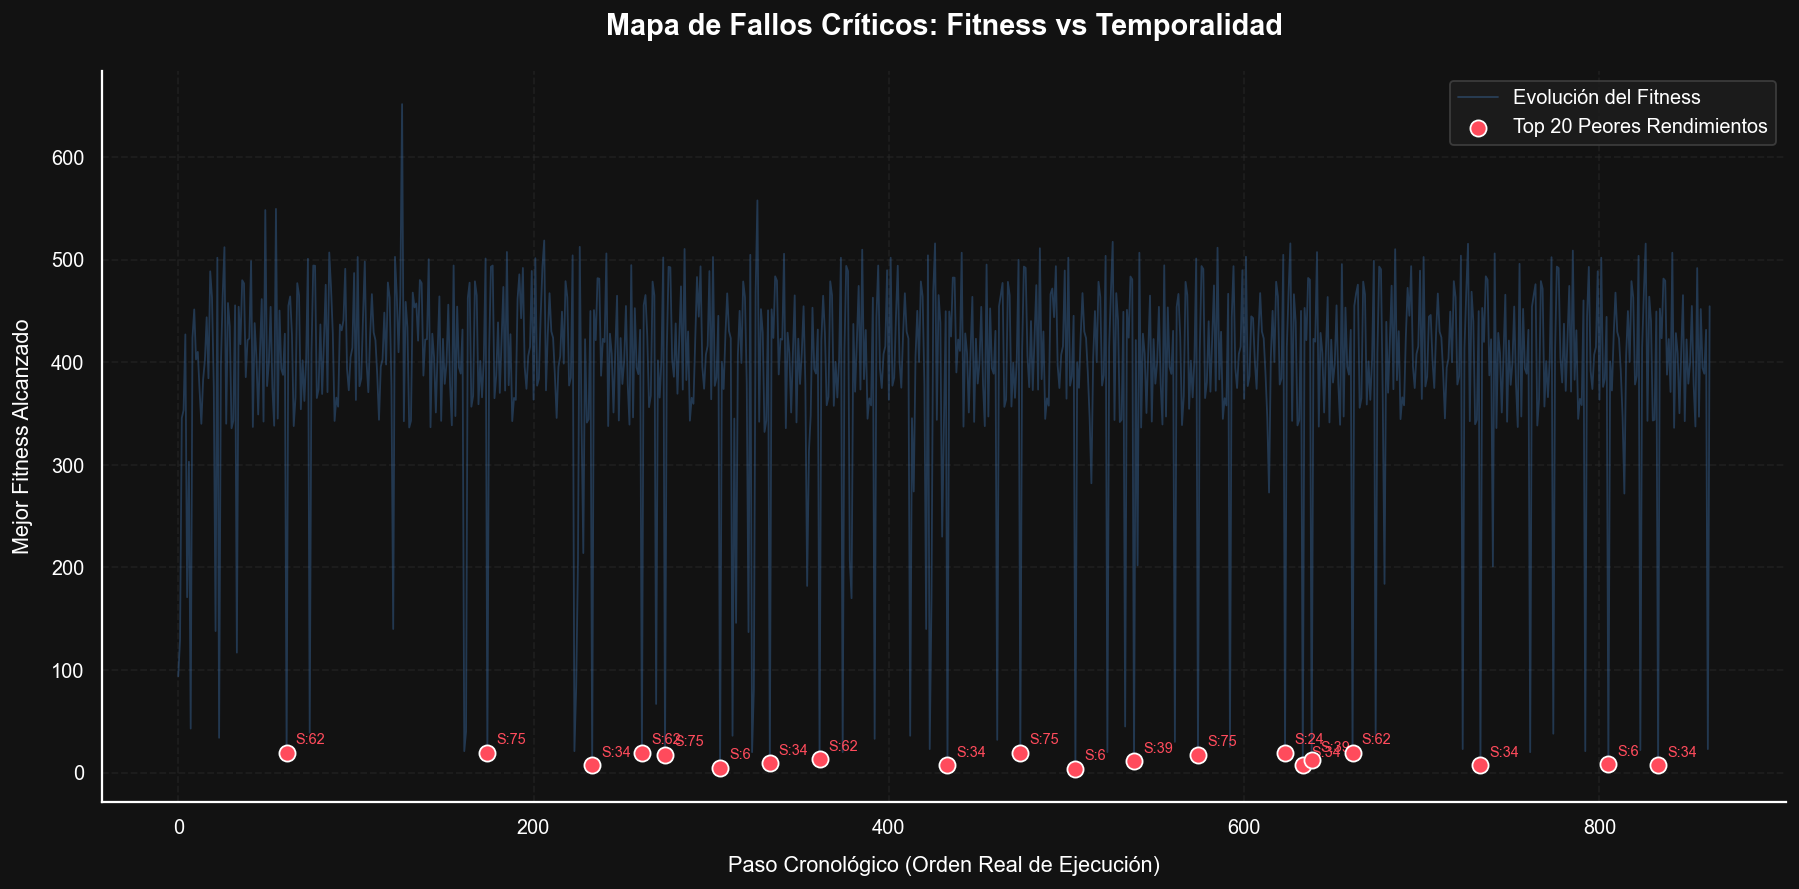

📉 LAS 20 GENERACIONES CON PEORES RESULTADOS (SIN PESOS):
 seed  generation  best_fitness  avg_progress
    6         506           4.0          3.53
    6         306           5.0          4.93
   34         234           7.0          5.90
   34         434           7.0          6.23
   34         634           7.0          5.30
   34         734           7.0          5.73
   34         834           7.0          5.20
    6         806           8.0          4.70
   34         334           9.0          6.83
   39         539          11.0         10.33
   39         639          12.0         11.00
   62         362          13.0         12.27
   75         275          17.0         14.87
   75         575          17.0         16.03
   62          62          19.0         14.57
   75         175          19.0         15.20
   62         262          19.0         13.87
   75         475          19.0         17.00
   24         624          19.0         18.07
   62         662      

In [27]:
df_clean = df.drop(columns=['weights_json'], errors='ignore')

# 2. Encontrar los 20 peores fitness históricos (los valores más bajos)
peores_20 = df_clean.nsmallest(20, 'best_fitness').copy()

# 3. Crear un 'Índice de Tiempo Real' 
# Esto nos permite ver si los fallos son al inicio o dispersos
df_clean['paso_cronologico'] = range(len(df_clean))
peores_20['paso_cronologico'] = peores_20.index

# 4. Configuración Estética (Fondo Oscuro Profesional)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#121212')

# --- GRÁFICA DE TODA LA DATA (Línea de tendencia de fondo) ---
ax.plot(df_clean['paso_cronologico'], df_clean['best_fitness'], 
        color='#4a90e2', alpha=0.3, linewidth=1, label='Evolución del Fitness')

# --- RESALTAR LOS 20 PEORES PUNTOS ---
# Usamos un color rojo vibrante y tamaño mayor para que destaquen
ax.scatter(peores_20['paso_cronologico'], peores_20['best_fitness'], 
           color='#ff4b5c', s=80, edgecolors='white', zorder=5, label='Top 20 Peores Rendimientos')

# 5. Estilización de Ejes y Títulos
ax.set_title('Mapa de Fallos Críticos: Fitness vs Temporalidad', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Paso Cronológico (Orden Real de Ejecución)', fontsize=12, labelpad=10)
ax.set_ylabel('Mejor Fitness Alcanzado', fontsize=12, labelpad=10)

# Cuadrícula sutil
ax.grid(True, color='#2a2a2a', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Añadir etiquetas a los peores puntos (Opcional: muestra la Seed en el punto)
for i, row in peores_20.iterrows():
    ax.annotate(f"S:{int(row['seed'])}", (row['paso_cronologico'], row['best_fitness']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='#ff4b5c')

plt.legend(facecolor='#1e1e1e', edgecolor='#444444', labelcolor='white')
plt.tight_layout()
plt.show()

# 6. Mostrar el DataFrame para análisis estadístico
print("📉 LAS 20 GENERACIONES CON PEORES RESULTADOS (SIN PESOS):")
print("="*70)
print(peores_20[['seed', 'generation', 'best_fitness', 'avg_progress']].to_string(index=False))

Calculando estadísticas de pesos (puede tardar unos segundos)...
         EDA — TRAINING LOG (Neuroevolución)

📐 Shape            : (863, 13)
🔁 Generaciones     : 1 → 863
🌱 Seeds únicas     : 100  (0 → 99)
📊 Registros/seed   : 8.6 promedio
🏆 Best fitness max : 651.46  (gen 127)
📉 Best fitness min : 4.00
🔍 Nulos totales    : 0

────────────────────────────────────────────────────────────
       generation  best_fitness  avg_progress   w_mean    w_std  w_abs_mean
count     863.000       863.000       863.000  863.000  863.000     863.000
mean      432.000       391.808       243.683   -0.472   13.417      10.887
std       249.271       108.045       104.829    0.692    4.556       3.655
min         1.000         4.000         3.530   -1.729    0.428       0.329
25%       216.500       366.015       182.050   -1.048    9.863       8.425
50%       432.000       409.490       256.730   -0.571   14.983      11.891
75%       647.500       455.360       317.765    0.204   17.107      13.777
ma

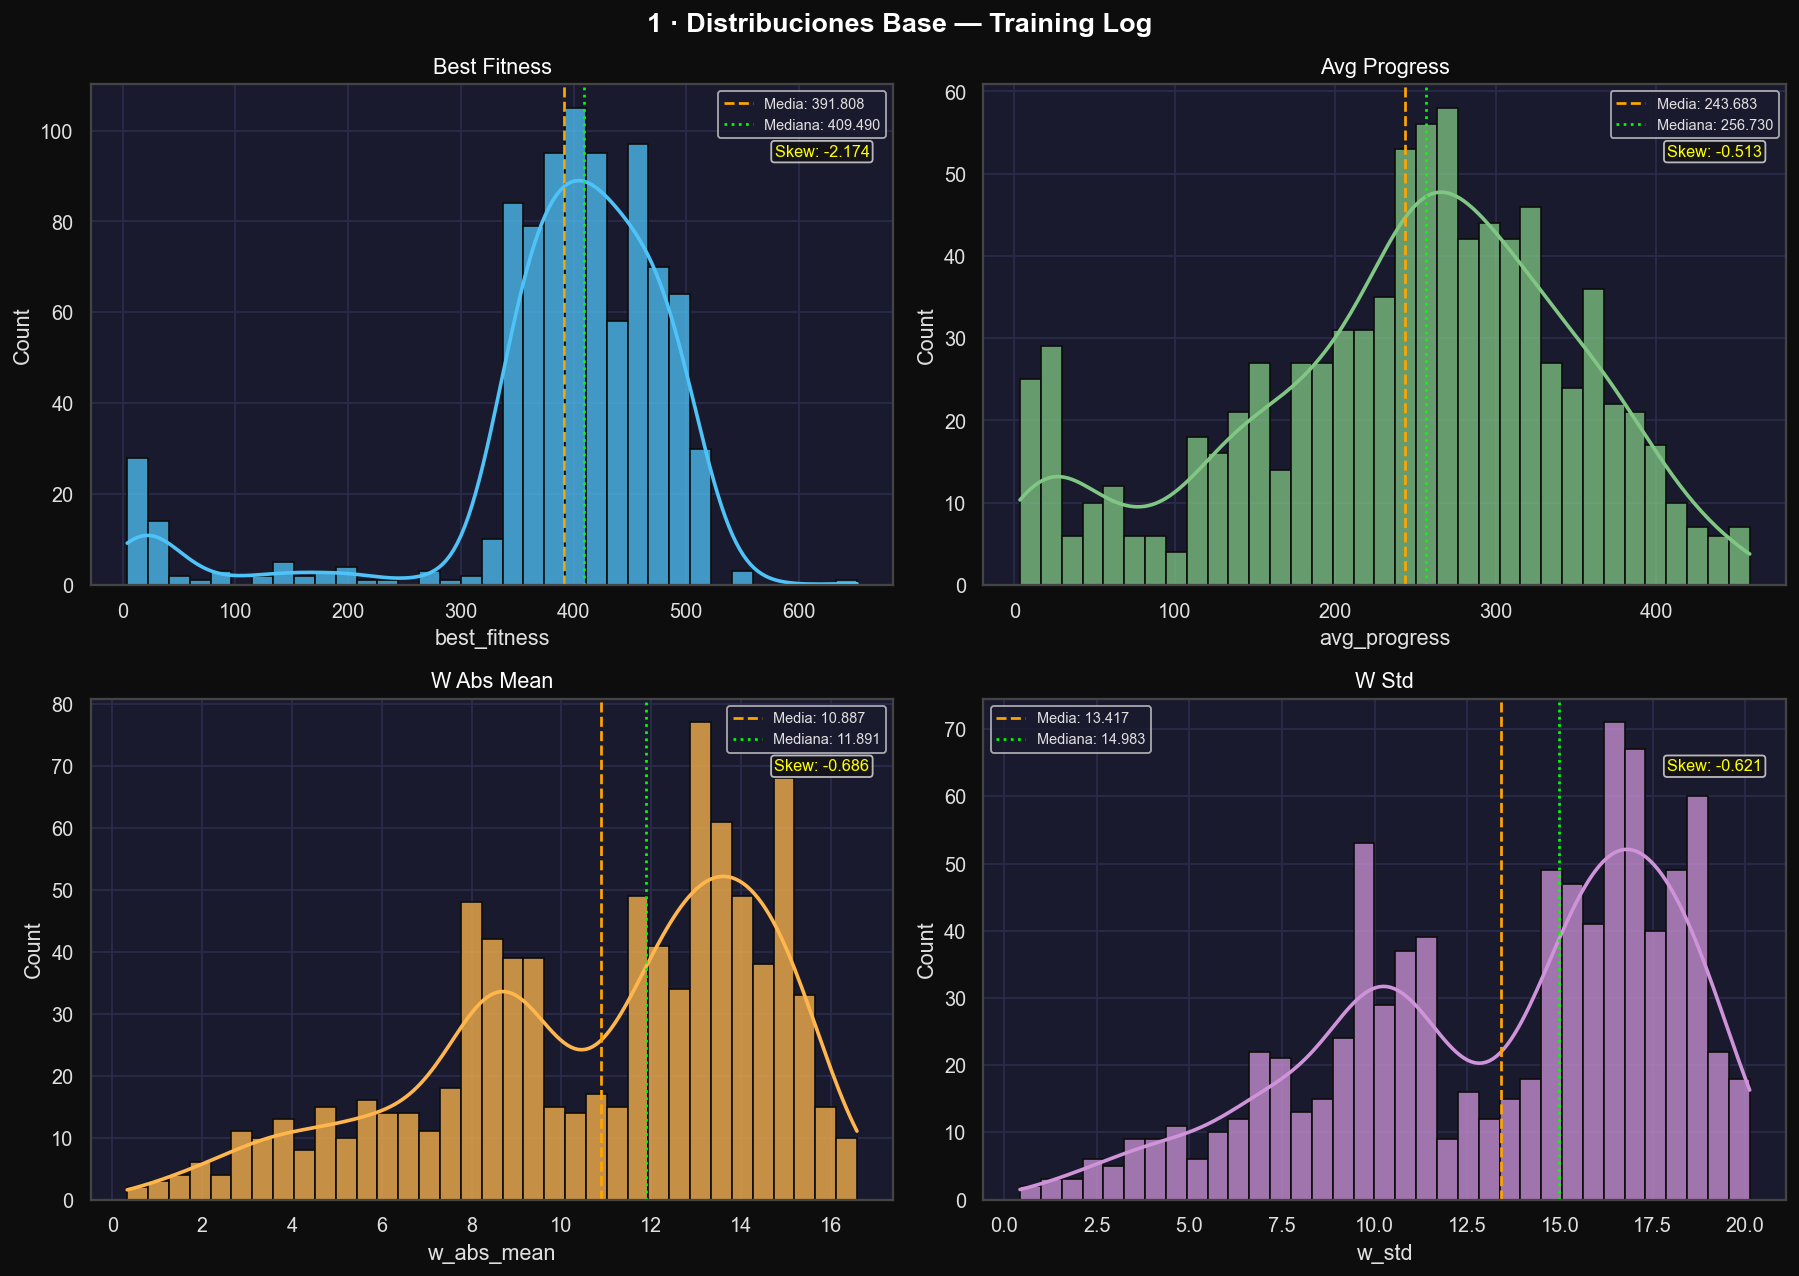

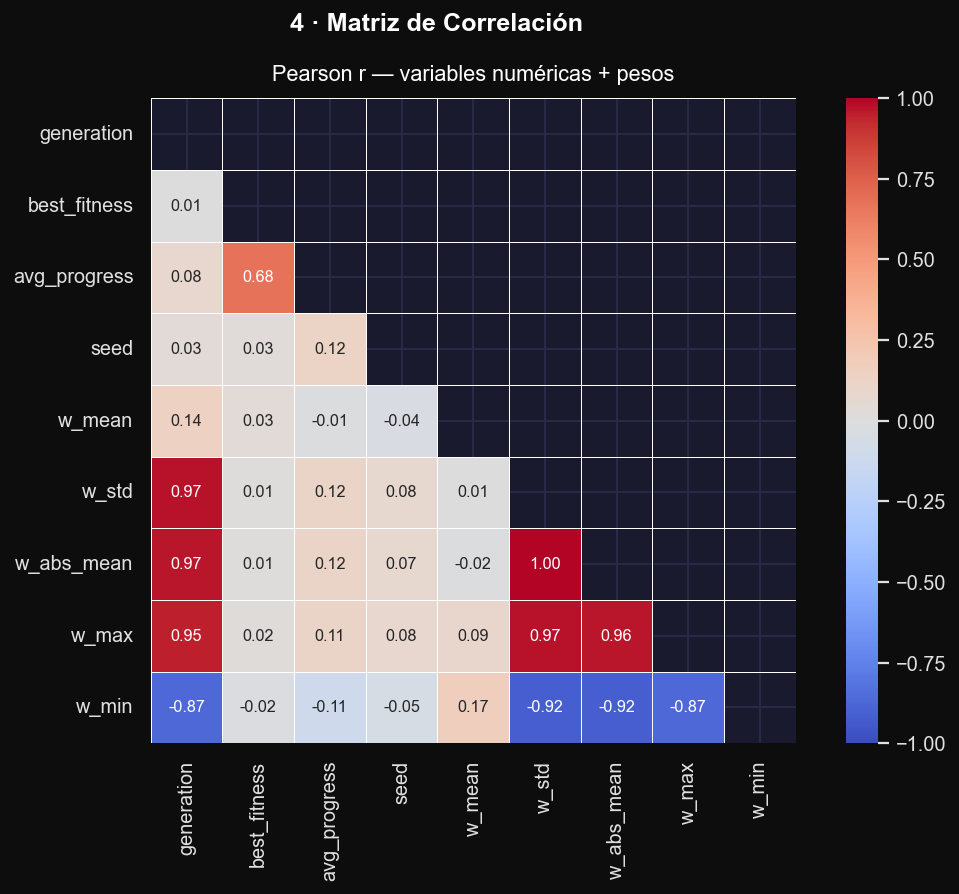

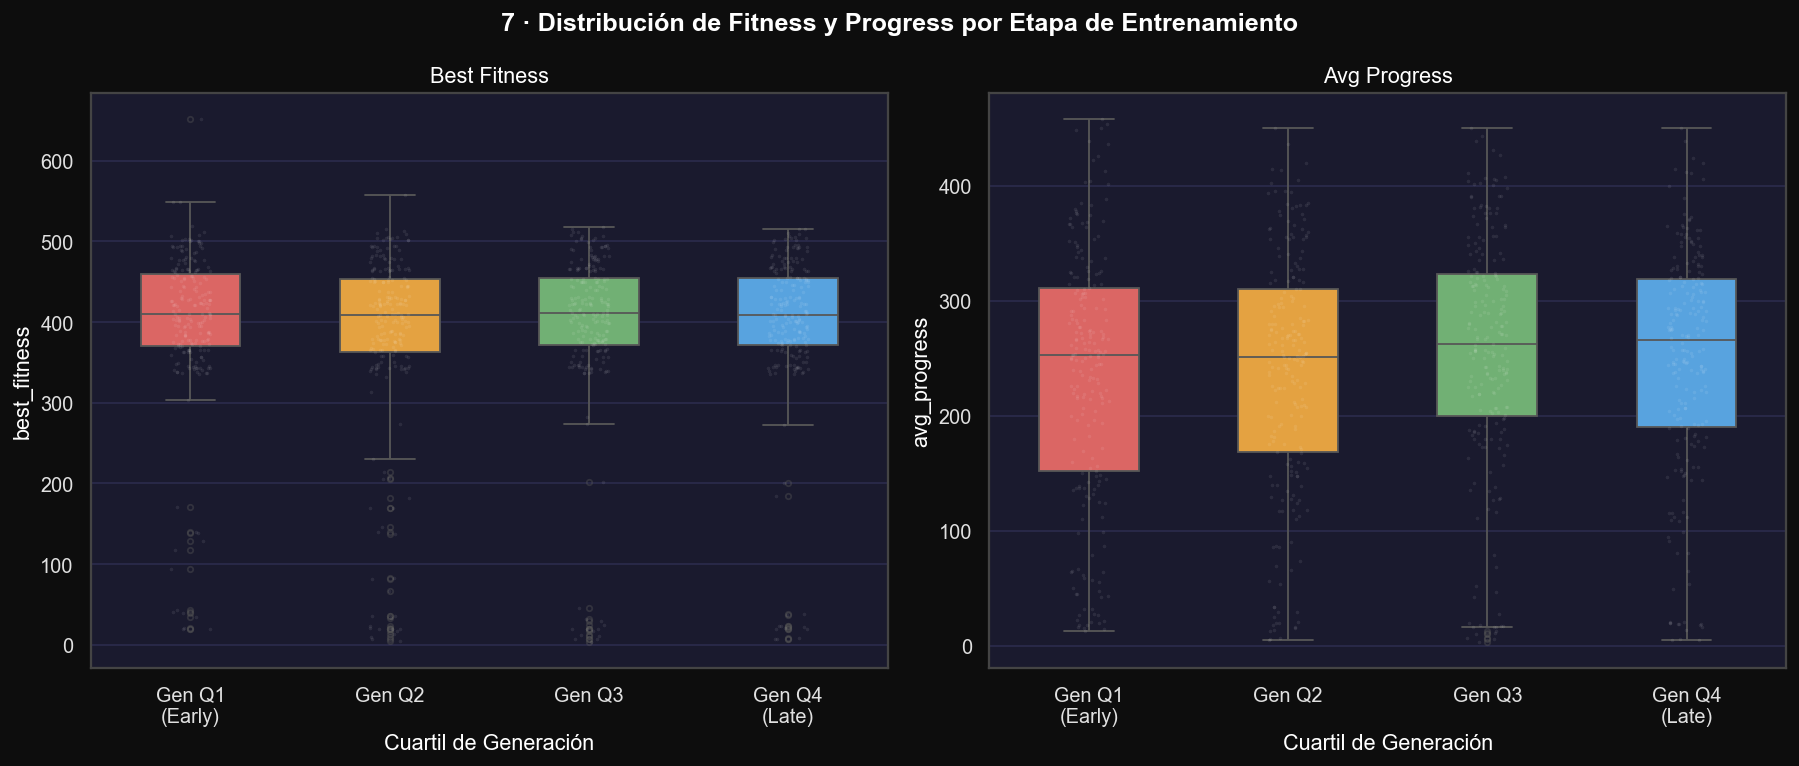

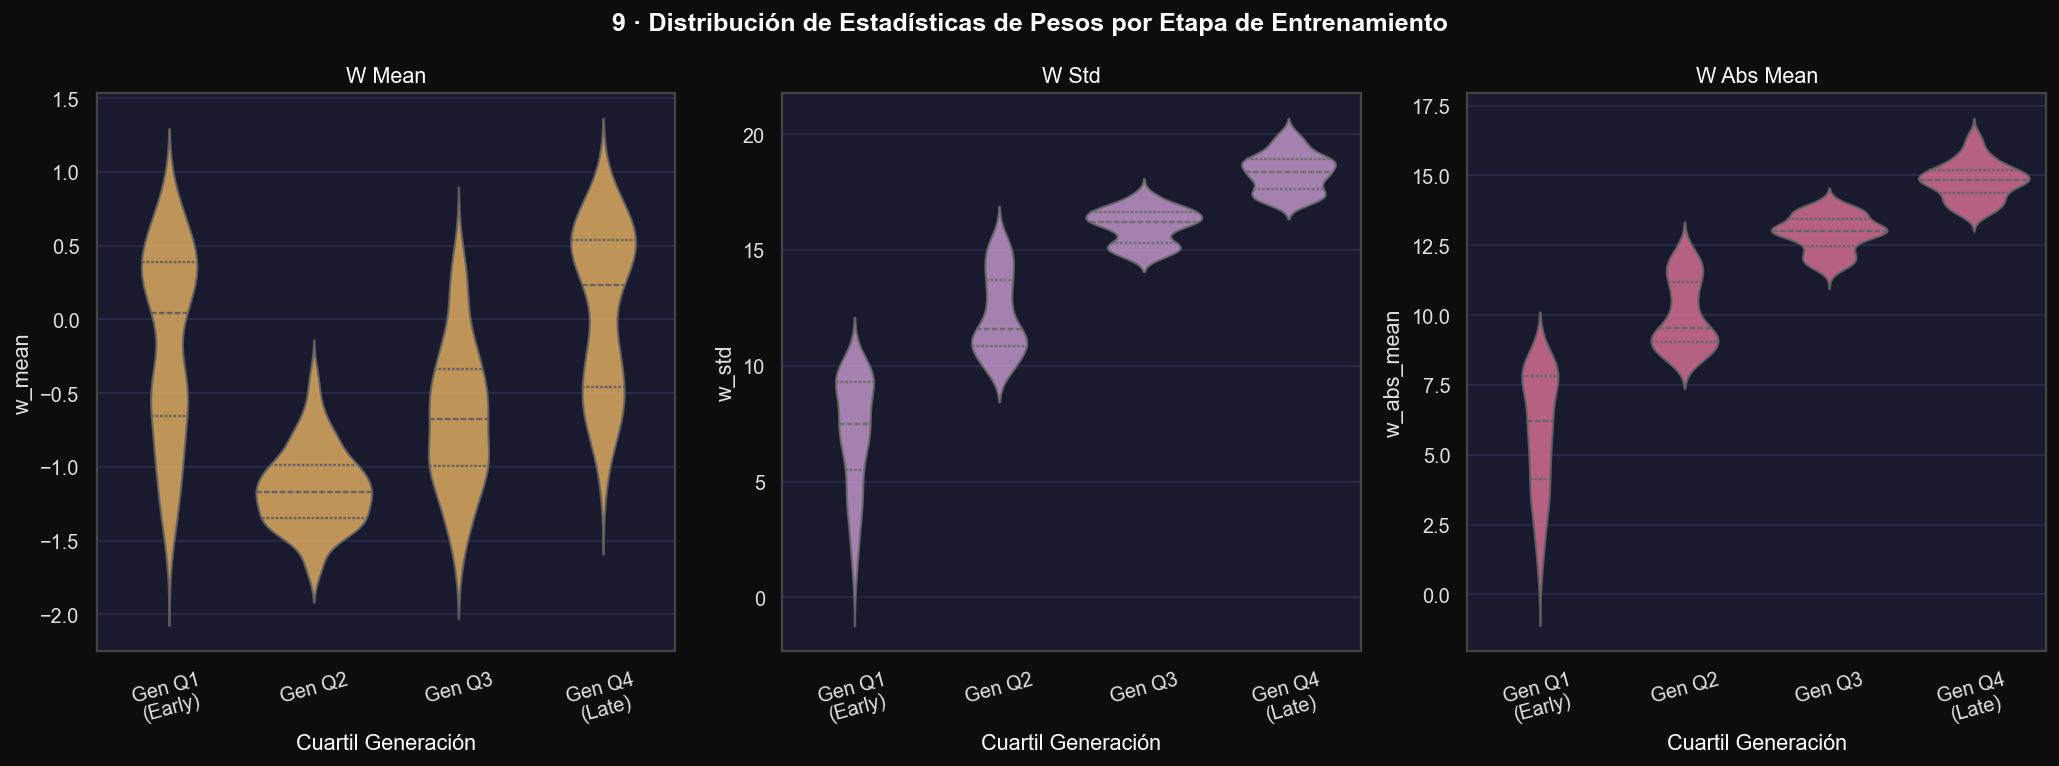

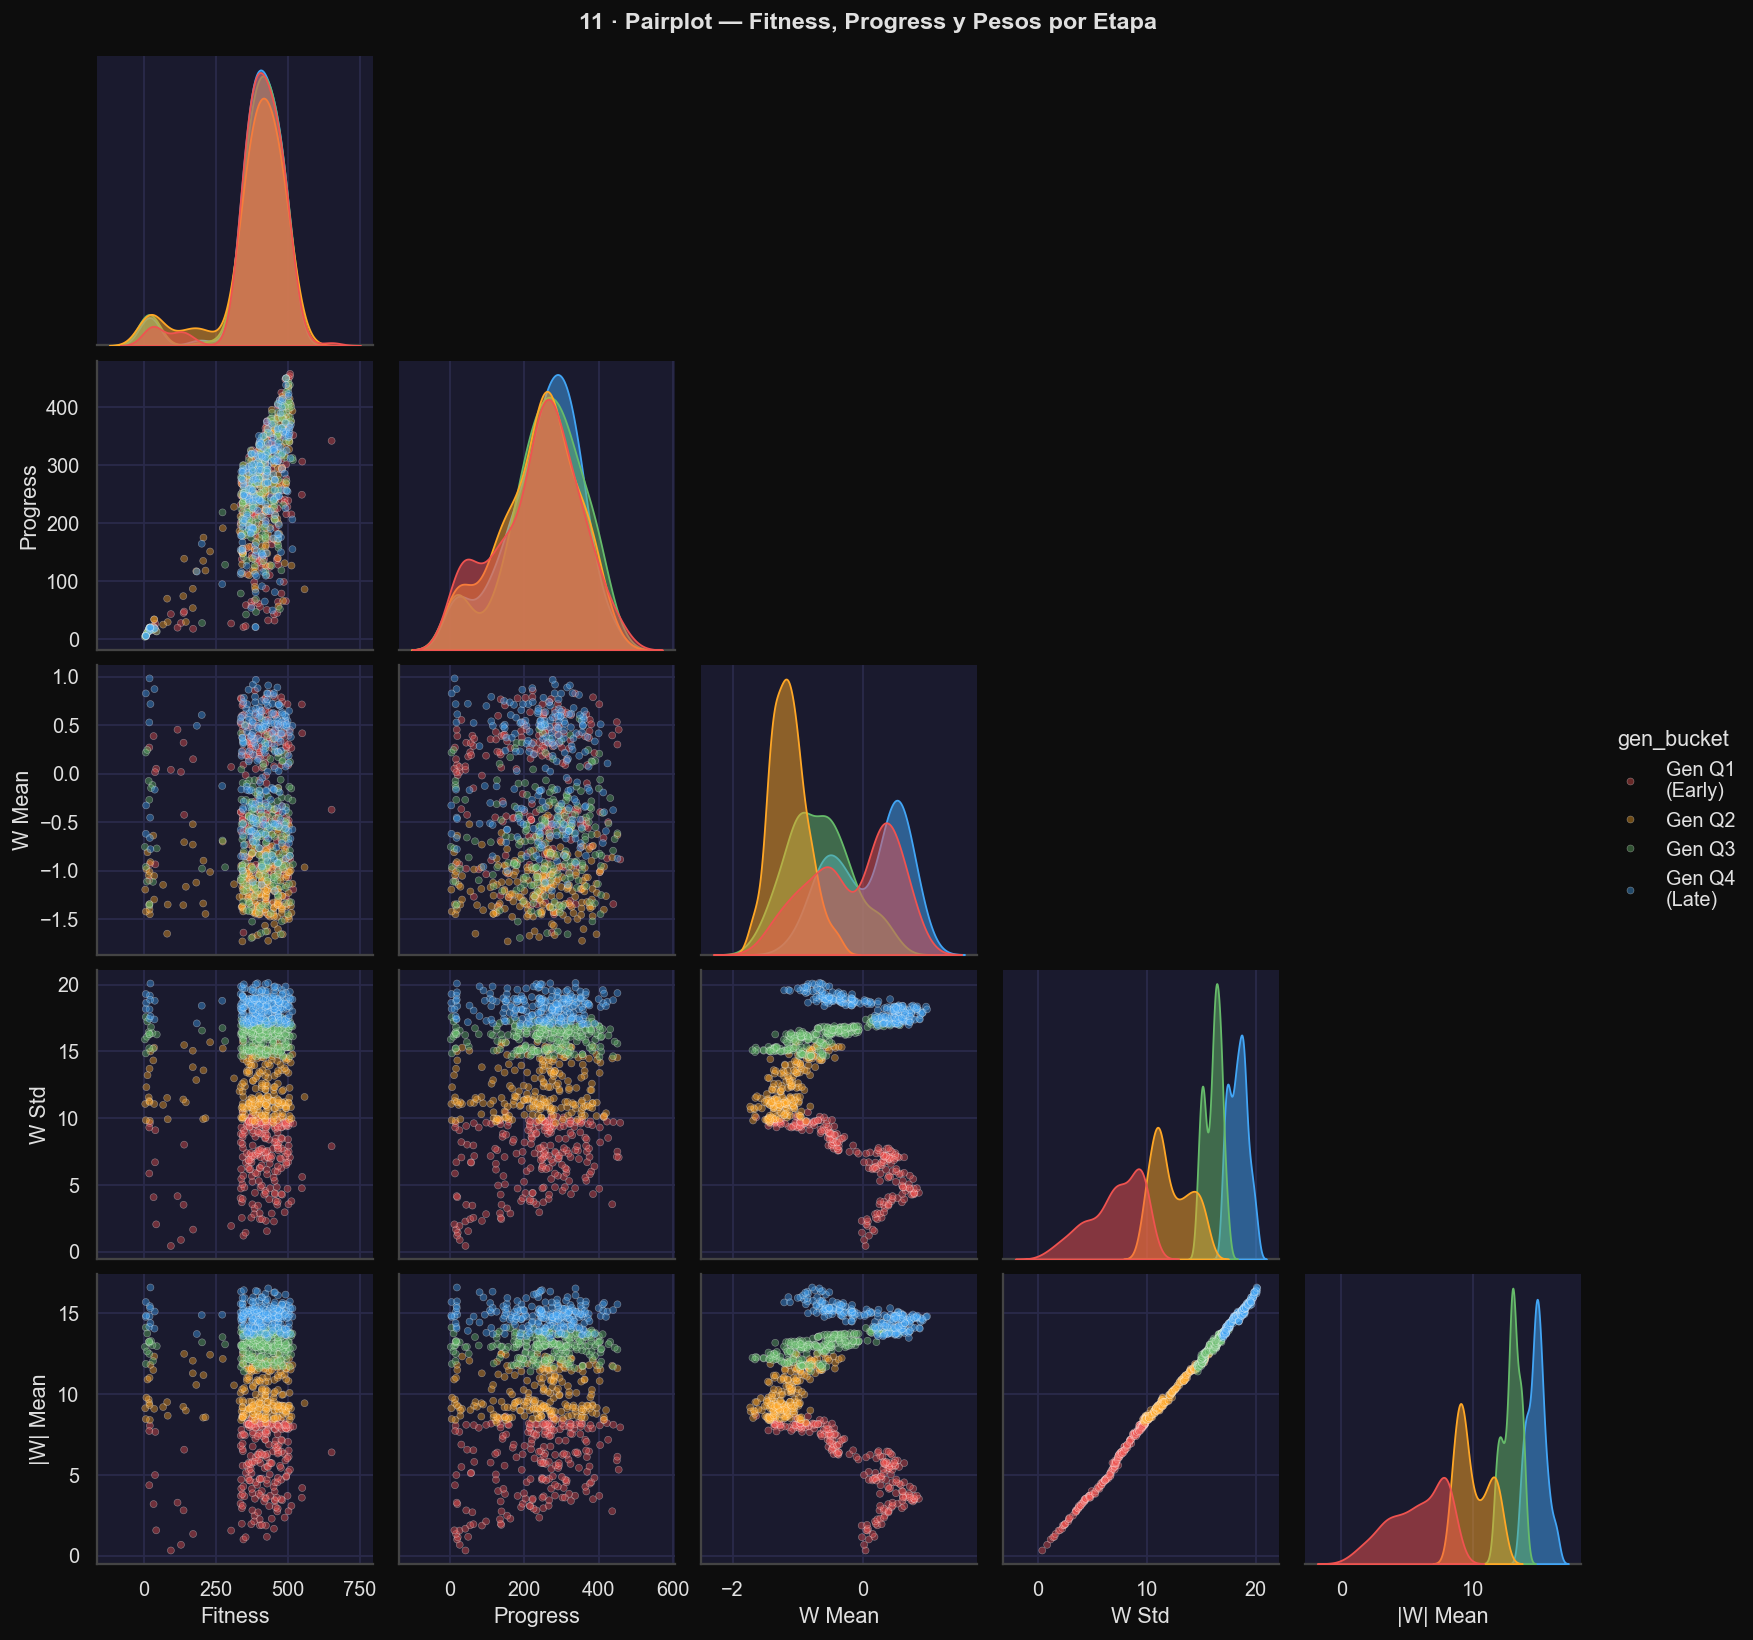

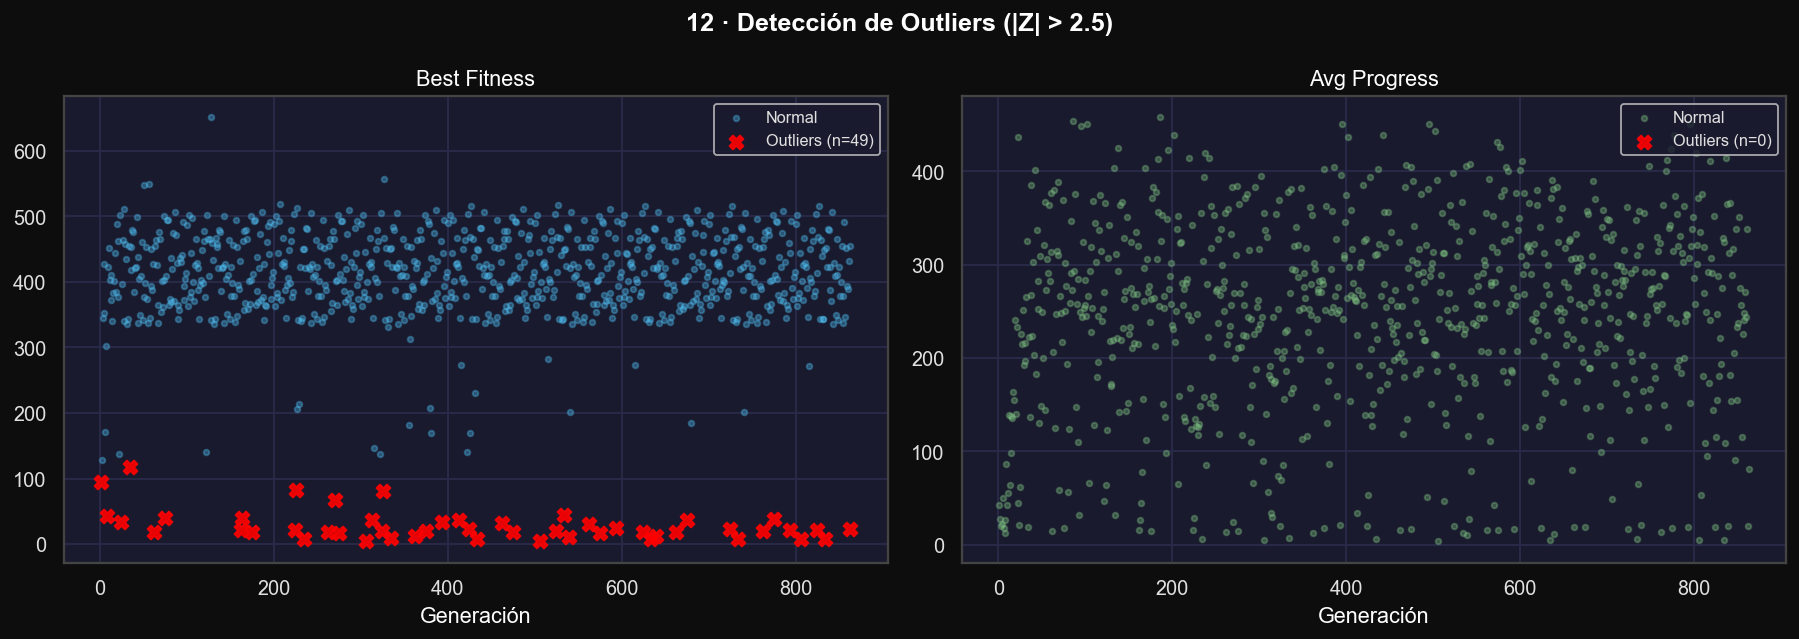

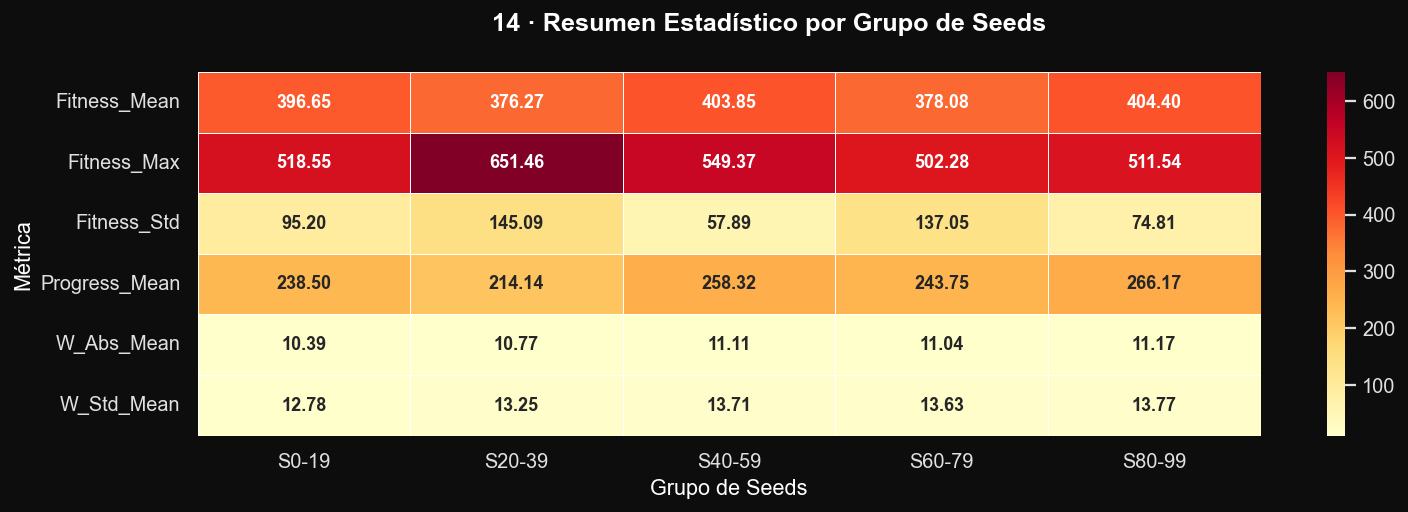


✅ EDA completado — 14 visualizaciones generadas.

📊 Mejor seed overall: 27 (max fitness: 651.46)
📉 Peor seed overall: 62 (max fitness: 32.00)

🔬 Correlación generation↔fitness : 0.0067
🔬 Correlación |W|↔fitness         : 0.0136
🔬 Correlación W_std↔fitness       : 0.0128


In [28]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.edgecolor': '#444',
    'grid.color': '#2a2a4a',
})

# ─────────────────────────────────────────────
# CARGA Y PREPARACIÓN
# ─────────────────────────────────────────────
df2 = pd.read_csv('training_log.csv')

# Extraer pesos por capa
def parse_weights(w_str):
    layers = ast.literal_eval(w_str)
    flat = []
    for layer in layers:
        flat.extend(np.array(layer).flatten().tolist())
    return flat

# Metadatos de pesos (sin aplanar todo — costoso)
def weight_stats(w_str):
    layers = ast.literal_eval(w_str)
    all_w = np.concatenate([np.array(l).flatten() for l in layers])
    return pd.Series({
        'w_mean': all_w.mean(),
        'w_std': all_w.std(),
        'w_abs_mean': np.abs(all_w).mean(),
        'w_max': all_w.max(),
        'w_min': all_w.min(),
    })

print("Calculando estadísticas de pesos (puede tardar unos segundos)...")
weight_meta = df2['weights_json'].apply(weight_stats)
df2 = pd.concat([df2, weight_meta], axis=1)

# Buckets de generación
df2['gen_bucket'] = pd.qcut(df2['generation'], q=4, labels=['Gen Q1\n(Early)', 'Gen Q2', 'Gen Q3', 'Gen Q4\n(Late)'])
df2['fitness_gain'] = df2.groupby('seed')['best_fitness'].diff()  # delta fitness por seed
df2['seed_bin'] = pd.cut(df2['seed'], bins=5, labels=['S0-19','S20-39','S40-59','S60-79','S80-99'])

print("=" * 60)
print("         EDA — TRAINING LOG (Neuroevolución)")
print("=" * 60)
print(f"\n📐 Shape            : {df2.shape}")
print(f"🔁 Generaciones     : {df2['generation'].min()} → {df2['generation'].max()}")
print(f"🌱 Seeds únicas     : {df2['seed'].nunique()}  (0 → 99)")
print(f"📊 Registros/seed   : {df2.groupby('seed').size().mean():.1f} promedio")
print(f"🏆 Best fitness max : {df2['best_fitness'].max():.2f}  (gen {df2.loc[df2['best_fitness'].idxmax(), 'generation']})")
print(f"📉 Best fitness min : {df2['best_fitness'].min():.2f}")
print(f"🔍 Nulos totales    : {df2[['generation','best_fitness','avg_progress','seed']].isnull().sum().sum()}")
print(f"\n{'─'*60}")
print(df2[['generation','best_fitness','avg_progress','w_mean','w_std','w_abs_mean']].describe().round(3).to_string())

# ─────────────────────────────────────────────
# 1. OVERVIEW — distribuciones numéricas base (Seaborn)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('1 · Distribuciones Base — Training Log', fontsize=15, fontweight='bold', color='white')

cols_plot = [('best_fitness', '#4fc3f7'), ('avg_progress', '#81c784'),
             ('w_abs_mean', '#ffb74d'), ('w_std', '#ce93d8')]

for ax, (col, color) in zip(axes.flat, cols_plot):
    sns.histplot(df2[col], bins=35, kde=True, ax=ax, color=color,
                 edgecolor='#0d0d0d', alpha=0.75, line_kws={'linewidth': 2})
    mu, med = df2[col].mean(), df2[col].median()
    ax.axvline(mu,  color='orange', linestyle='--', linewidth=1.5, label=f'Media: {mu:.3f}')
    ax.axvline(med, color='lime',   linestyle=':',  linewidth=1.5, label=f'Mediana: {med:.3f}')
    skw = df2[col].skew()
    ax.set_title(col.replace('_', ' ').title(), color='white')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.88, f'Skew: {skw:.3f}', transform=ax.transAxes,
            ha='right', va='top', color='yellow', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#111', alpha=0.7))

plt.tight_layout()
plt.savefig('01_distribuciones_base.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 2. EVOLUCIÓN FITNESS A LO LARGO DE GENERACIONES (Plotly)
# ─────────────────────────────────────────────
gen_stats = df2.groupby('generation').agg(
    fitness_mean=('best_fitness', 'mean'),
    fitness_max=('best_fitness', 'max'),
    fitness_min=('best_fitness', 'min'),
    fitness_std=('best_fitness', 'std'),
    progress_mean=('avg_progress', 'mean'),
    progress_std=('avg_progress', 'std'),
).reset_index()

fig2 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     subplot_titles=['Best Fitness por Generación', 'Avg Progress por Generación'],
                     vertical_spacing=0.08)

# Banda ±1 std fitness
fig2.add_trace(go.Scatter(
    x=pd.concat([gen_stats['generation'], gen_stats['generation'][::-1]]),
    y=pd.concat([gen_stats['fitness_mean'] + gen_stats['fitness_std'],
                 (gen_stats['fitness_mean'] - gen_stats['fitness_std'])[::-1]]),
    fill='toself', fillcolor='rgba(79,195,247,0.12)',
    line=dict(color='rgba(0,0,0,0)'), name='±1 Std Fitness', showlegend=True
), row=1, col=1)
fig2.add_trace(go.Scatter(x=gen_stats['generation'], y=gen_stats['fitness_mean'],
    mode='lines', name='Media Fitness', line=dict(color='#4fc3f7', width=2)), row=1, col=1)
fig2.add_trace(go.Scatter(x=gen_stats['generation'], y=gen_stats['fitness_max'],
    mode='lines', name='Máx Fitness', line=dict(color='lime', dash='dot', width=1.2)), row=1, col=1)
fig2.add_trace(go.Scatter(x=gen_stats['generation'], y=gen_stats['fitness_min'],
    mode='lines', name='Mín Fitness', line=dict(color='salmon', dash='dot', width=1.2)), row=1, col=1)

# Banda ±1 std progress
fig2.add_trace(go.Scatter(
    x=pd.concat([gen_stats['generation'], gen_stats['generation'][::-1]]),
    y=pd.concat([gen_stats['progress_mean'] + gen_stats['progress_std'],
                 (gen_stats['progress_mean'] - gen_stats['progress_std'])[::-1]]),
    fill='toself', fillcolor='rgba(129,199,132,0.12)',
    line=dict(color='rgba(0,0,0,0)'), name='±1 Std Progress', showlegend=True
), row=2, col=1)
fig2.add_trace(go.Scatter(x=gen_stats['generation'], y=gen_stats['progress_mean'],
    mode='lines', name='Media Progress', line=dict(color='#81c784', width=2)), row=2, col=1)

fig2.update_layout(title='2 · Curva de Aprendizaje — Fitness & Progress vs Generación',
                   template='plotly_dark', height=600,
                   xaxis2_title='Generación',
                   legend=dict(orientation='h', y=-0.12))
fig2.show()

# ─────────────────────────────────────────────
# 3. EVOLUCIÓN DE PESOS A LO LARGO DEL ENTRENAMIENTO (Plotly)
# ─────────────────────────────────────────────
weight_gen = df2.groupby('generation').agg(
    w_mean_avg=('w_mean', 'mean'),
    w_std_avg=('w_std', 'mean'),
    w_abs_mean_avg=('w_abs_mean', 'mean'),
).reset_index()

fig3 = make_subplots(rows=1, cols=3,
                     subplot_titles=['Media de Pesos', 'Std de Pesos', '|Media| de Pesos'])

for col_i, (col, color, name) in enumerate([
    ('w_mean_avg', '#ffb74d', 'W Mean'),
    ('w_std_avg', '#ce93d8', 'W Std'),
    ('w_abs_mean_avg', '#f06292', '|W| Mean')
], 1):
    fig3.add_trace(go.Scatter(x=weight_gen['generation'], y=weight_gen[col],
        mode='lines', name=name, line=dict(color=color, width=1.8)), row=1, col=col_i)
    # Línea suavizada (rolling)
    smooth = weight_gen[col].rolling(window=20, min_periods=1).mean()
    fig3.add_trace(go.Scatter(x=weight_gen['generation'], y=smooth,
        mode='lines', name=f'{name} (smooth)', line=dict(color='white', width=2, dash='dot'),
        showlegend=(col_i == 1)), row=1, col=col_i)

fig3.update_layout(title='3 · Evolución de Estadísticas de Pesos por Generación',
                   template='plotly_dark', height=420,
                   legend=dict(orientation='h', y=-0.2))
fig3.show()

# ─────────────────────────────────────────────
# 4. CORRELACIÓN ENTRE VARIABLES (Seaborn)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('4 · Matriz de Correlación', fontsize=14, fontweight='bold', color='white')

corr_cols = ['generation', 'best_fitness', 'avg_progress', 'seed',
             'w_mean', 'w_std', 'w_abs_mean', 'w_max', 'w_min']
corr = df2[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Pearson r — variables numéricas + pesos', color='white', pad=10)
plt.tight_layout()
plt.savefig('04_correlacion.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 5. FITNESS POR SEED — trayectorias individuales (Plotly)
# ─────────────────────────────────────────────
fig5 = go.Figure()

# Muestra 20 seeds representativas (cada 5)
seeds_sample = sorted(df2['seed'].unique())[::5]
colorscale = px.colors.sequential.Plasma
color_map = {s: colorscale[int(i / len(seeds_sample) * (len(colorscale) - 1))]
             for i, s in enumerate(seeds_sample)}

for seed in seeds_sample:
    sub = df2[df2['seed'] == seed].sort_values('generation')
    fig5.add_trace(go.Scatter(
        x=sub['generation'], y=sub['best_fitness'],
        mode='lines', name=f'Seed {seed}',
        line=dict(color=color_map[seed], width=1.2), opacity=0.75
    ))

# Media global encima
fig5.add_trace(go.Scatter(
    x=gen_stats['generation'], y=gen_stats['fitness_mean'],
    mode='lines', name='Media Global',
    line=dict(color='white', width=3, dash='dash')
))

fig5.update_layout(
    title='5 · Trayectorias de Best Fitness por Seed (muestra cada 5)',
    xaxis_title='Generación', yaxis_title='Best Fitness',
    template='plotly_dark', height=500,
    legend=dict(orientation='h', y=-0.18, font=dict(size=9))
)
fig5.show()
# ─────────────────────────────────────────────
# 6. SCATTER FITNESS vs PROGRESS — coloreado por generación (Plotly go) — FIXED v2
# ─────────────────────────────────────────────
from plotly.subplots import make_subplots

fig6 = make_subplots(
    rows=2, cols=2,
    column_widths=[0.8, 0.2],
    row_heights=[0.2, 0.8],
    shared_xaxes=True,
    shared_yaxes=True,
)

# Scatter principal (fila 2, col 1)
fig6.add_trace(go.Scatter(
    x=df2['avg_progress'],
    y=df2['best_fitness'],
    mode='markers',
    marker=dict(
        size=4,
        opacity=0.6,
        color=df2['generation'],
        colorscale='Viridis',
        colorbar=dict(title='Generación', x=1.02),
        showscale=True
    ),
    text=df2['generation'],
    hovertemplate='Progress: %{x:.1f}<br>Fitness: %{y:.1f}<br>Gen: %{text}<extra></extra>',
    name='Observaciones'
), row=2, col=1)

# Histograma marginal superior (avg_progress)
fig6.add_trace(go.Histogram(
    x=df2['avg_progress'],
    nbinsx=40,
    marker_color='#4fc3f7',
    opacity=0.7,
    name='Dist Progress',
    showlegend=False
), row=1, col=1)

# Histograma marginal derecho (best_fitness)
fig6.add_trace(go.Histogram(
    y=df2['best_fitness'],
    nbinsy=40,
    marker_color='#81c784',
    opacity=0.7,
    name='Dist Fitness',
    showlegend=False
), row=2, col=2)

fig6.update_layout(
    title='6 · Best Fitness vs Avg Progress (color = generación)',
    template='plotly_dark',
    height=580,
    showlegend=False,
    xaxis2_title='Avg Progress',
    yaxis2_title='Best Fitness',
)
fig6.show()
# ─────────────────────────────────────────────
# 7. BOXPLOTS FITNESS Y PROGRESS POR CUARTIL DE GENERACIÓN (Seaborn)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('7 · Distribución de Fitness y Progress por Etapa de Entrenamiento',
             fontsize=14, fontweight='bold', color='white')

palette_q = {'Gen Q1\n(Early)': '#ef5350', 'Gen Q2': '#ffa726',
             'Gen Q3': '#66bb6a', 'Gen Q4\n(Late)': '#42a5f5'}

for ax, col, title in zip(axes,
                           ['best_fitness', 'avg_progress'],
                           ['Best Fitness', 'Avg Progress']):
    sns.boxplot(data=df2, x='gen_bucket', y=col, ax=ax,
                palette=palette_q, width=0.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    sns.stripplot(data=df2, x='gen_bucket', y=col, ax=ax,
                  color='white', alpha=0.08, size=2, jitter=True)
    ax.set_title(title, color='white')
    ax.set_xlabel('Cuartil de Generación', color='white')
    ax.set_ylabel(col, color='white')

plt.tight_layout()
plt.savefig('07_boxplot_gen_quartile.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 8. HEATMAP — FITNESS PROMEDIO POR SEED × GENERACIÓN BUCKET (Plotly)
# ─────────────────────────────────────────────
df2['gen_10'] = (df2['generation'] // 10) * 10  # buckets de 10 generaciones
pivot = df2.groupby(['seed', 'gen_10'])['best_fitness'].mean().unstack(fill_value=np.nan)

fig8 = px.imshow(pivot, color_continuous_scale='RdYlGn',
                 aspect='auto',
                 title='8 · Heatmap — Best Fitness Promedio por Seed × Bloque de 10 Generaciones',
                 labels={'x': 'Generación (bloque 10)', 'y': 'Seed', 'color': 'Fitness'},
                 template='plotly_dark', height=600)
fig8.update_layout(coloraxis_colorbar=dict(title='Fitness'))
fig8.show()

# ─────────────────────────────────────────────
# 9. DISTRIBUCIÓN DE PESOS — VIOLINPLOT POR CUARTIL GEN (Seaborn)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('9 · Distribución de Estadísticas de Pesos por Etapa de Entrenamiento',
             fontsize=14, fontweight='bold', color='white')

for ax, col, color in zip(axes,
                           ['w_mean', 'w_std', 'w_abs_mean'],
                           ['#ffb74d', '#ce93d8', '#f06292']):
    sns.violinplot(data=df2, x='gen_bucket', y=col, ax=ax,
                   color=color, inner='quartile', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), color='white')
    ax.set_xlabel('Cuartil Generación', color='white')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('09_violin_pesos.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 10. ANÁLISIS DE CONVERGENCIA — Delta Fitness (Plotly)
# ─────────────────────────────────────────────
delta_gen = df2.groupby('generation')['fitness_gain'].agg(['mean','std']).reset_index()
delta_gen.columns = ['generation', 'delta_mean', 'delta_std']
delta_gen = delta_gen.dropna()

fig10 = go.Figure()
fig10.add_trace(go.Bar(
    x=delta_gen['generation'], y=delta_gen['delta_mean'],
    marker=dict(color=delta_gen['delta_mean'],
                colorscale='RdYlGn', cmin=-5, cmax=5,
                colorbar=dict(title='Δ Fitness')),
    name='Δ Fitness Media', opacity=0.8
))
fig10.add_trace(go.Scatter(
    x=delta_gen['generation'],
    y=delta_gen['delta_mean'].rolling(30, min_periods=1).mean(),
    mode='lines', name='Tendencia (rolling 30)',
    line=dict(color='white', width=2.5)
))
fig10.add_hline(y=0, line=dict(color='red', dash='dash', width=1), opacity=0.6)

fig10.update_layout(
    title='10 · Δ Best Fitness por Generación — Velocidad de Convergencia',
    xaxis_title='Generación', yaxis_title='ΔFitness (media entre seeds)',
    template='plotly_dark', height=450
)
fig10.show()

# ─────────────────────────────────────────────
# 11. DISPERSIÓN PESOS vs FITNESS (Seaborn pairplot)
# ─────────────────────────────────────────────
pair_df = df2[['best_fitness', 'avg_progress', 'w_mean', 'w_std', 'w_abs_mean', 'gen_bucket']].copy()
pair_df = pair_df.rename(columns={
    'best_fitness': 'Fitness', 'avg_progress': 'Progress',
    'w_mean': 'W Mean', 'w_std': 'W Std', 'w_abs_mean': '|W| Mean'
})

g = sns.pairplot(pair_df, hue='gen_bucket', corner=True,
                 palette={'Gen Q1\n(Early)': '#ef5350', 'Gen Q2': '#ffa726',
                          'Gen Q3': '#66bb6a', 'Gen Q4\n(Late)': '#42a5f5'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'alpha': 0.5})
g.figure.suptitle('11 · Pairplot — Fitness, Progress y Pesos por Etapa',
                   y=1.01, fontsize=13, fontweight='bold')
plt.savefig('11_pairplot.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 12. OUTLIERS — Z-Score en fitness y progress (Matplotlib)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('12 · Detección de Outliers (|Z| > 2.5)', fontsize=14, fontweight='bold', color='white')

for ax, col, color in zip(axes, ['best_fitness', 'avg_progress'], ['#4fc3f7', '#81c784']):
    z = np.abs(stats.zscore(df2[col]))
    mask_out = z > 2.5
    ax.scatter(df2.loc[~mask_out, 'generation'], df2.loc[~mask_out, col],
               alpha=0.35, s=10, color=color, label='Normal')
    ax.scatter(df2.loc[mask_out, 'generation'], df2.loc[mask_out, col],
               alpha=0.9, s=60, color='red', marker='X',
               label=f'Outliers (n={mask_out.sum()})', zorder=5)
    ax.set_title(col.replace('_', ' ').title(), color='white')
    ax.set_xlabel('Generación', color='white')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('12_outliers.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 13. TOP & BOTTOM 10 SEEDS POR FITNESS FINAL (Plotly)
# ─────────────────────────────────────────────
seed_summary = df2.groupby('seed').agg(
    max_fitness=('best_fitness', 'max'),
    mean_fitness=('best_fitness', 'mean'),
    final_fitness=('best_fitness', 'last'),
    n_gens=('generation', 'count')
).reset_index().sort_values('max_fitness', ascending=False)

top10 = seed_summary.head(10)
bot10 = seed_summary.tail(10)
combined = pd.concat([top10, bot10])
combined['group'] = ['Top 10'] * 10 + ['Bottom 10'] * 10

fig13 = px.bar(combined, x='seed', y='max_fitness', color='group',
               color_discrete_map={'Top 10': '#4caf50', 'Bottom 10': '#f44336'},
               text='max_fitness',
               title='13 · Top 10 vs Bottom 10 Seeds por Max Fitness',
               labels={'seed': 'Seed', 'max_fitness': 'Max Best Fitness'},
               template='plotly_dark', height=430)
fig13.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig13.show()

# ─────────────────────────────────────────────
# 14. RESUMEN ESTADÍSTICO FINAL — HEATMAP (Seaborn)
# ─────────────────────────────────────────────
summary = df2.groupby('seed_bin').agg(
    Fitness_Mean=('best_fitness', 'mean'),
    Fitness_Max=('best_fitness', 'max'),
    Fitness_Std=('best_fitness', 'std'),
    Progress_Mean=('avg_progress', 'mean'),
    W_Abs_Mean=('w_abs_mean', 'mean'),
    W_Std_Mean=('w_std', 'mean'),
).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('14 · Resumen Estadístico por Grupo de Seeds',
             fontsize=14, fontweight='bold', color='white')
sns.heatmap(summary.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10, 'fontweight': 'bold'})
ax.set_xlabel('Grupo de Seeds', color='white')
ax.set_ylabel('Métrica', color='white')
plt.tight_layout()
plt.savefig('14_resumen_seeds.png', bbox_inches='tight')
plt.show()

print("\n✅ EDA completado — 14 visualizaciones generadas.")
print(f"\n📊 Mejor seed overall: {seed_summary.iloc[0]['seed']:.0f} "
      f"(max fitness: {seed_summary.iloc[0]['max_fitness']:.2f})")
print(f"📉 Peor seed overall: {seed_summary.iloc[-1]['seed']:.0f} "
      f"(max fitness: {seed_summary.iloc[-1]['max_fitness']:.2f})")
print(f"\n🔬 Correlación generation↔fitness : {df2['generation'].corr(df2['best_fitness']):.4f}")
print(f"🔬 Correlación |W|↔fitness         : {df2['w_abs_mean'].corr(df2['best_fitness']):.4f}")
print(f"🔬 Correlación W_std↔fitness       : {df2['w_std'].corr(df2['best_fitness']):.4f}")

In [29]:
df2 = pd.read_csv('tournament_metrics.csv')
df2

,Seed,Ronda,Coche,Color,Terminado,Progreso_Pct,Tiempo_Lap_Ticks,Puntaje_Final,Ganador
0,100,1,1,"(255, 0, 0)",True,100.00,223,369.84,True
1,100,1,2,"(0, 0, 255)",False,99.69,222,324.00,False
2,100,1,3,"(0, 255, 255)",False,98.46,222,320.00,False
3,100,1,4,"(255, 165, 0)",False,98.77,222,321.00,False
4,100,1,5,"(0, 128, 0)",False,98.46,222,320.00,False
...,...,...,...,...,...,...,...,...,...
145,129,30,1,"(255, 0, 0)",False,98.75,247,395.00,False
146,129,30,2,"(0, 0, 255)",True,100.00,247,440.49,True
147,129,30,3,"(0, 255, 255)",False,99.00,246,396.00,False
148,129,30,4,"(255, 165, 0)",False,97.50,246,390.00,False


           EDA — TOURNAMENT METRICS

📐 Shape         : (150, 11)
📋 Columnas      : ['Seed', 'Ronda', 'Coche', 'Color', 'Terminado', 'Progreso_Pct', 'Tiempo_Lap_Ticks', 'Puntaje_Final', 'Ganador', 'Color_Name', 'Color_Hex']
🔍 Nulos totales : 0
🎲 Seeds únicas  : 30
🏁 Rondas únicas : 30
🚗 Coches únicos : 5

───────────────────────────────────────────────────────
                  count    mean     std     min     25%    50%     75%     max
Seed              150.0  114.50    8.68  100.00  107.00  114.5  122.00  129.00
Ronda             150.0   15.50    8.68    1.00    8.00   15.5   23.00   30.00
Coche             150.0    3.00    1.42    1.00    2.00    3.0    4.00    5.00
Progreso_Pct      150.0   84.66   25.63    1.65   76.64   98.0   99.54  106.33
Tiempo_Lap_Ticks  150.0  219.09   47.60   20.00  209.25  232.0  242.00  359.00
Puntaje_Final     150.0  320.93  108.32    7.00  271.25  324.0  396.88  508.51


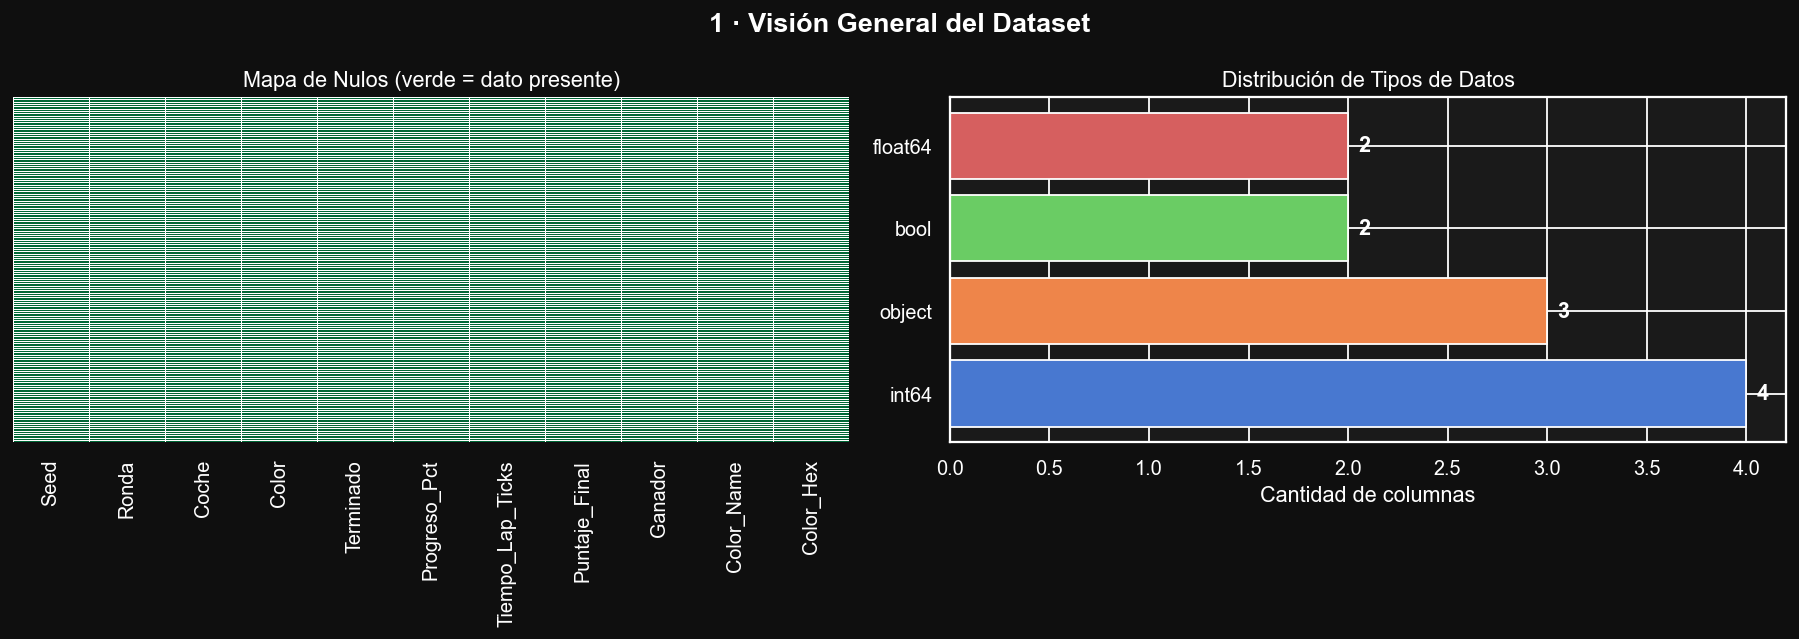

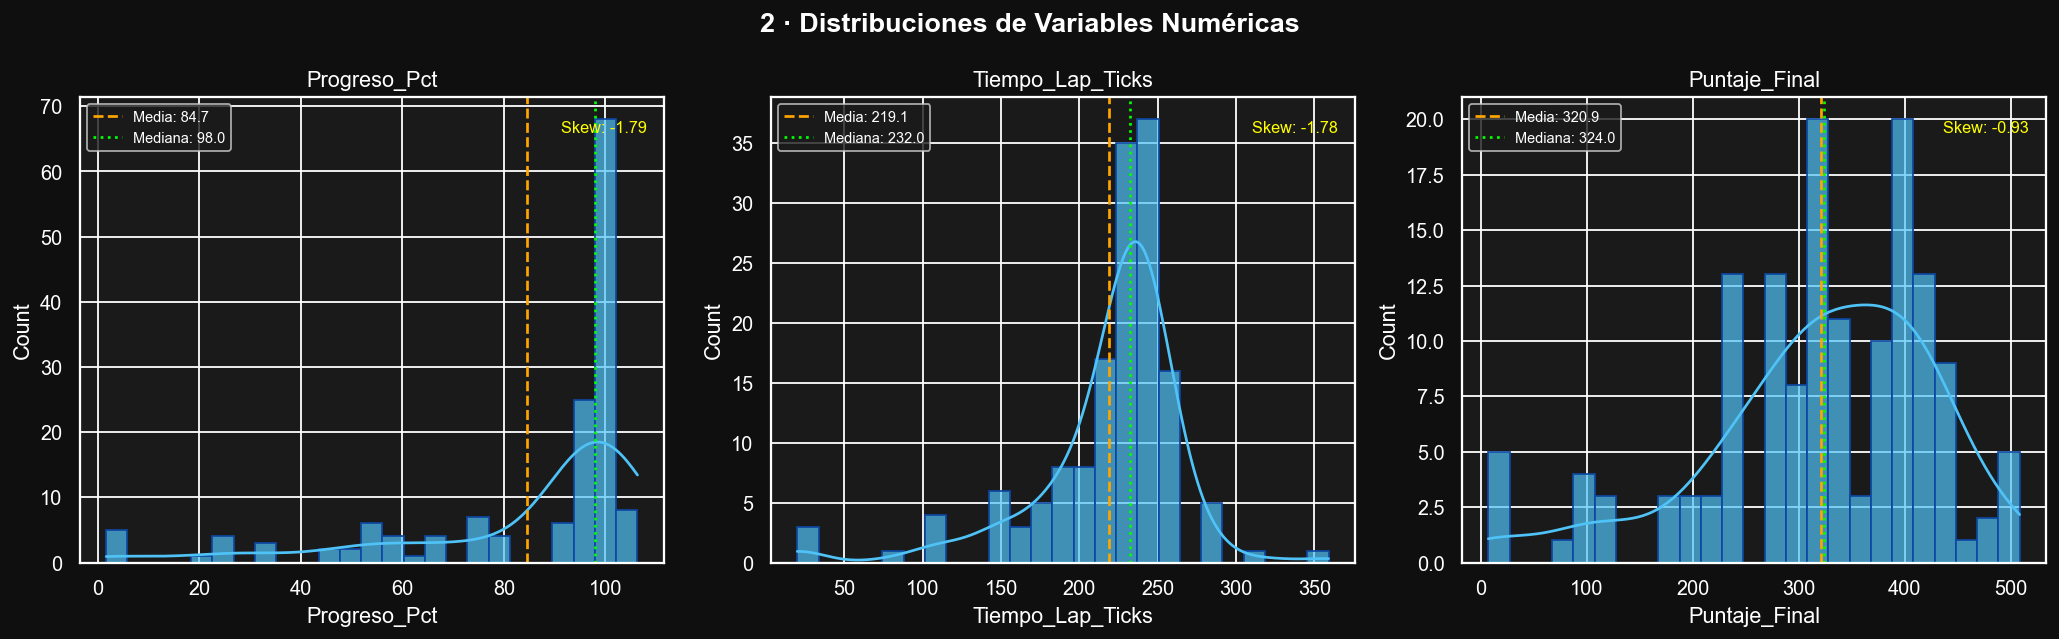

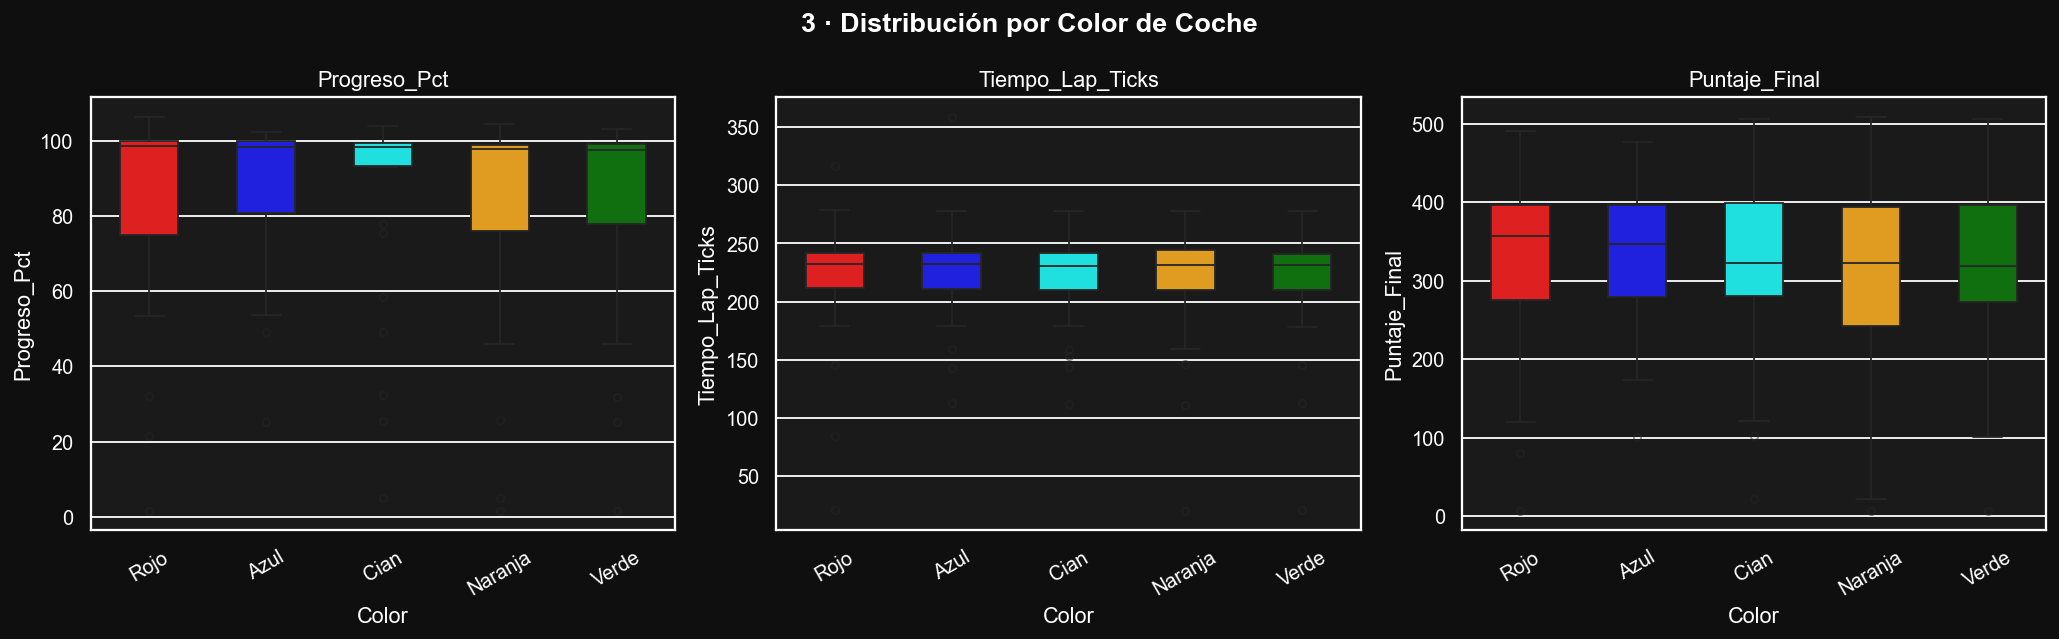

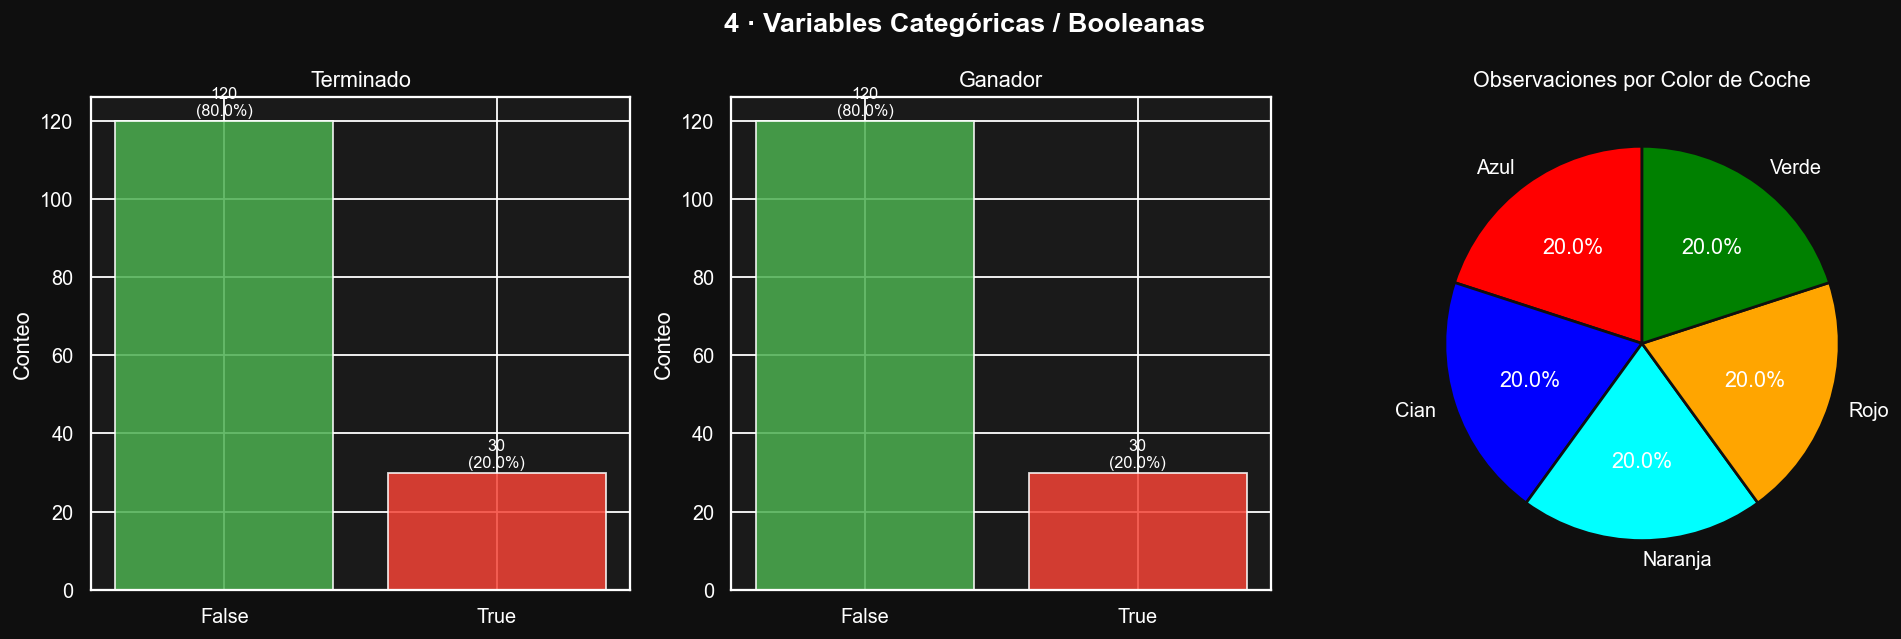

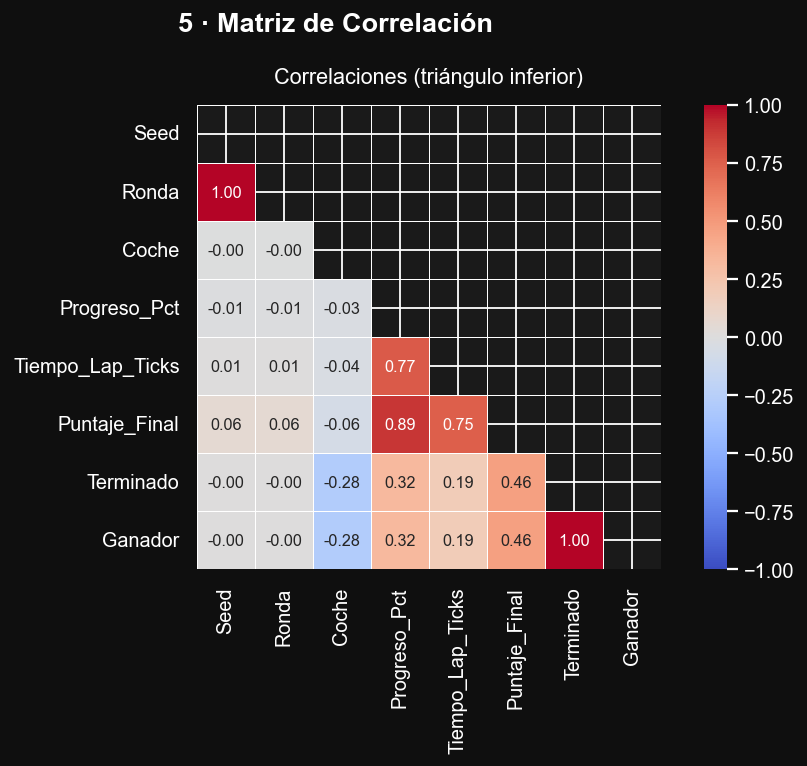

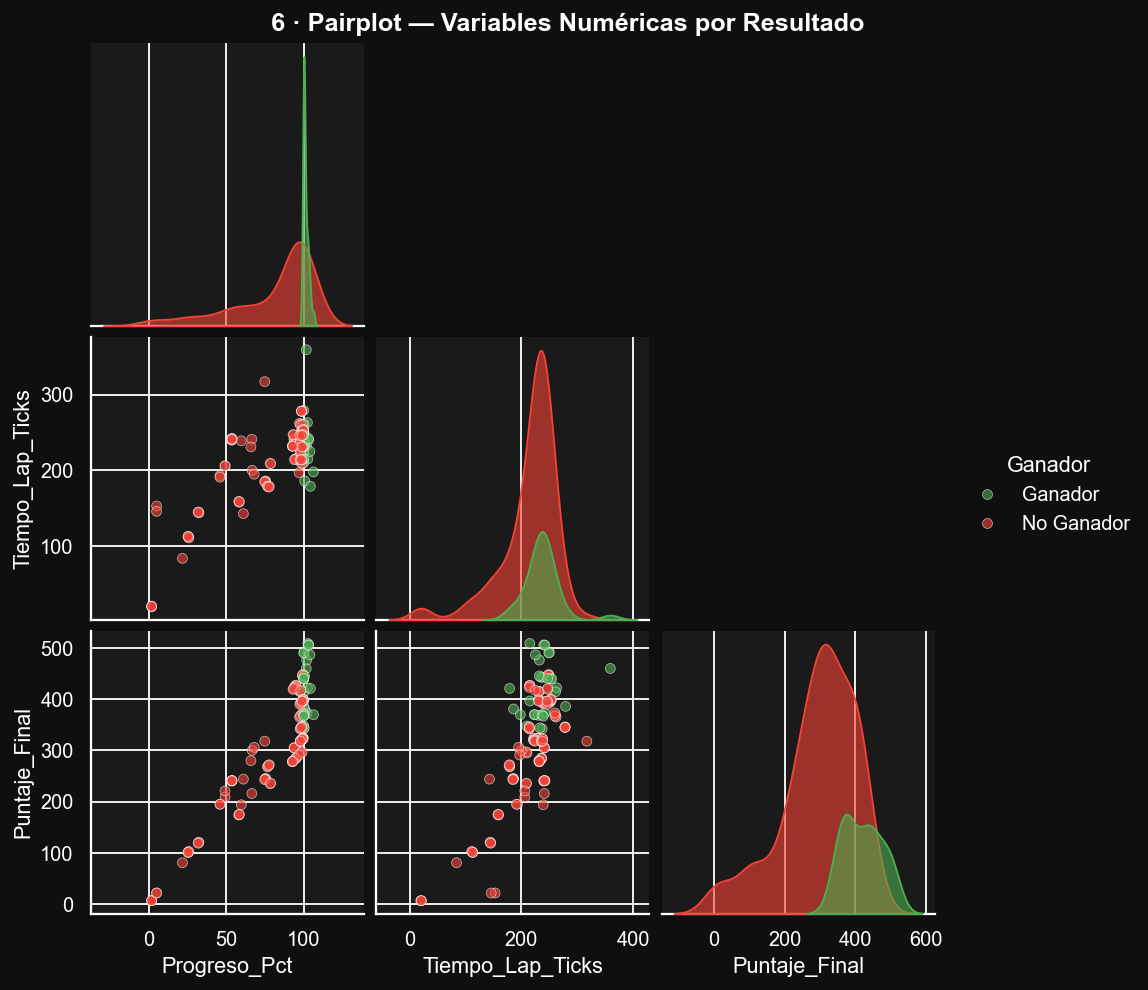

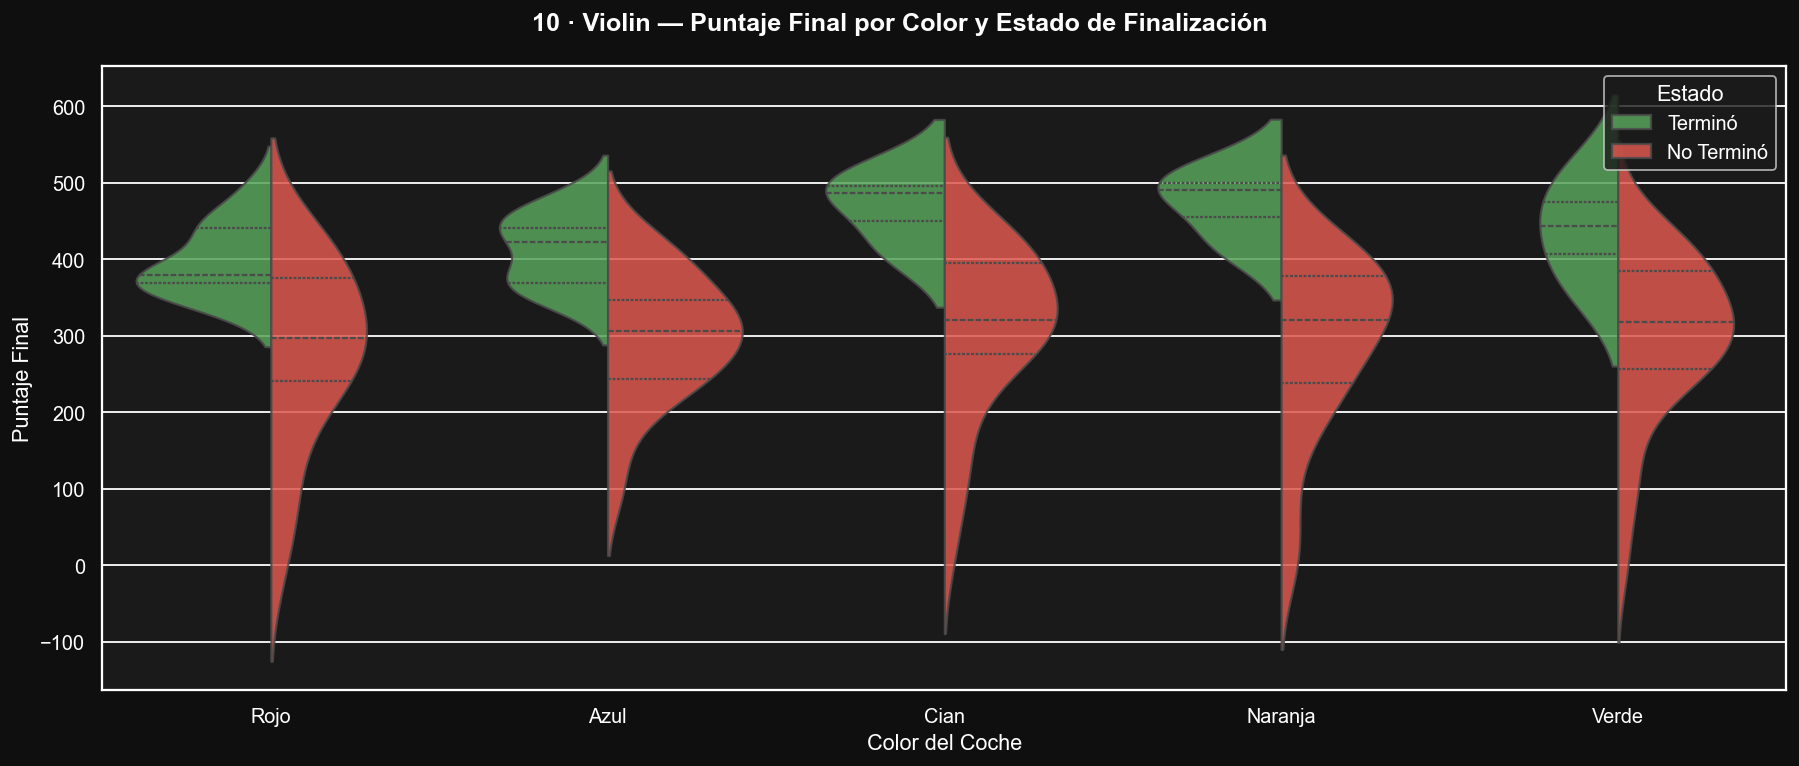

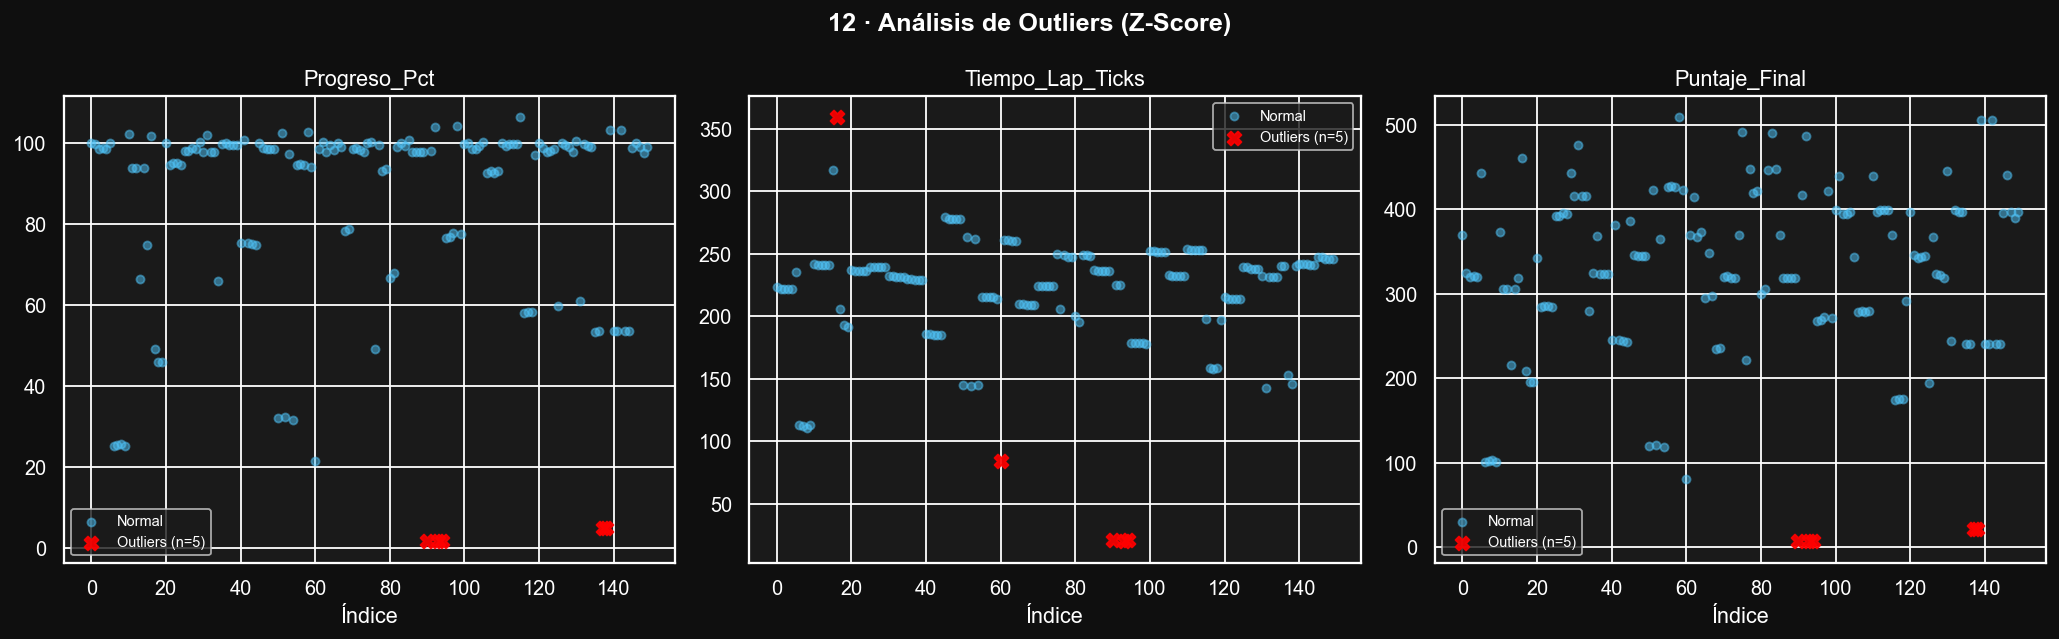

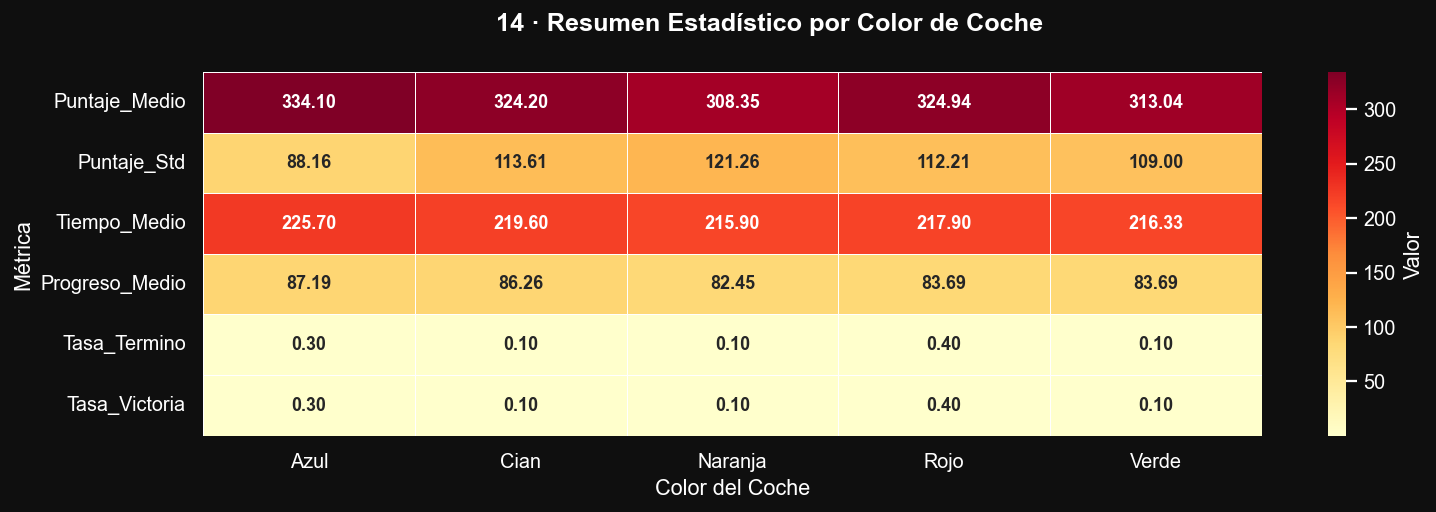


✅ EDA completado — 14 visualizaciones generadas.
            Puntaje_Medio  Puntaje_Std  Tiempo_Medio  Progreso_Medio  Tasa_Termino  Tasa_Victoria
Color_Name                                                                                       
Azul               334.10        88.16        225.70           87.19           0.3            0.3
Cian               324.20       113.61        219.60           86.26           0.1            0.1
Naranja            308.35       121.26        215.90           82.45           0.1            0.1
Rojo               324.94       112.21        217.90           83.69           0.4            0.4
Verde              313.04       109.00        216.33           83.69           0.1            0.1


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': '#0f0f0f',
                     'axes.facecolor': '#1a1a1a', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'text.color': 'white', 'axes.titlecolor': 'white'})

COLOR_MAP = {
    '(255, 0, 0)': 'red',
    '(0, 0, 255)': 'blue',
    '(0, 255, 255)': 'cyan',
    '(255, 165, 0)': 'orange',
    '(0, 128, 0)': 'green'
}
COLOR_NAMES = {
    '(255, 0, 0)': 'Rojo',
    '(0, 0, 255)': 'Azul',
    '(0, 255, 255)': 'Cian',
    '(255, 165, 0)': 'Naranja',
    '(0, 128, 0)': 'Verde'
}

# ─────────────────────────────────────────────
# CARGA Y PREPARACIÓN
# ─────────────────────────────────────────────
df2 = pd.read_csv('tournament_metrics.csv')
df2['Color_Name'] = df2['Color'].map(COLOR_NAMES)
df2['Color_Hex'] = df2['Color'].map(COLOR_MAP)

print("=" * 55)
print("           EDA — TOURNAMENT METRICS")
print("=" * 55)
print(f"\n📐 Shape         : {df2.shape}")
print(f"📋 Columnas      : {list(df2.columns)}")
print(f"🔍 Nulos totales : {df2.isnull().sum().sum()}")
print(f"🎲 Seeds únicas  : {df2['Seed'].nunique()}")
print(f"🏁 Rondas únicas : {df2['Ronda'].nunique()}")
print(f"🚗 Coches únicos : {df2['Coche'].nunique()}")
print(f"\n{'─'*55}")
print(df2.describe().T.round(2).to_string())

# ─────────────────────────────────────────────
# 1. OVERVIEW — tipos de datos + nulos (Seaborn/Matplotlib)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1 · Visión General del Dataset', fontsize=15, fontweight='bold', color='white')

# 1a. Heatmap de nulos
mask_null = df2.isnull()
sns.heatmap(mask_null, cbar=False, cmap='RdYlGn_r', ax=axes[0],
            linewidths=0.5, yticklabels=False)
axes[0].set_title('Mapa de Nulos (verde = dato presente)', color='white')
axes[0].tick_params(colors='white')

# 1b. Conteo de tipos de datos
dtype_counts = df2.dtypes.astype(str).value_counts()
bars = axes[1].barh(dtype_counts.index, dtype_counts.values,
                    color=sns.color_palette('muted', len(dtype_counts)))
axes[1].set_title('Distribución de Tipos de Datos', color='white')
axes[1].set_xlabel('Cantidad de columnas', color='white')
for bar, val in zip(bars, dtype_counts.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('01_overview.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 2. DISTRIBUCIONES NUMÉRICAS (Seaborn — histplot + KDE)
# ─────────────────────────────────────────────
num_cols = ['Progreso_Pct', 'Tiempo_Lap_Ticks', 'Puntaje_Final']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('2 · Distribuciones de Variables Numéricas', fontsize=15, fontweight='bold', color='white')

for ax, col in zip(axes, num_cols):
    sns.histplot(df2[col], bins=25, kde=True, ax=ax,
                 color='#4fc3f7', edgecolor='#0d47a1', alpha=0.7)
    ax.axvline(df2[col].mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Media: {df2[col].mean():.1f}')
    ax.axvline(df2[col].median(), color='lime', linestyle=':', linewidth=1.5, label=f'Mediana: {df2[col].median():.1f}')
    ax.set_title(col, color='white')
    ax.legend(fontsize=8)
    skew = df2[col].skew()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', color='yellow', fontsize=9)
plt.tight_layout()
plt.savefig('02_distribuciones.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 3. BOXPLOTS POR COLOR DE COCHE (Seaborn)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('3 · Distribución por Color de Coche', fontsize=15, fontweight='bold', color='white')

palette = {cn: cv for cn, cv in zip(COLOR_NAMES.values(), COLOR_MAP.values())}

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df2, x='Color_Name', y=col, ax=ax,
                palette=palette, width=0.5, flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
    ax.set_title(col, color='white')
    ax.set_xlabel('Color', color='white')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('03_boxplots_color.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 4. VARIABLES CATEGÓRICAS — Terminado & Ganador (Seaborn)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('4 · Variables Categóricas / Booleanas', fontsize=15, fontweight='bold', color='white')

for ax, col in zip(axes[:2], ['Terminado', 'Ganador']):
    counts = df2[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=['#4caf50', '#f44336'], edgecolor='white', alpha=0.85)
    ax.set_title(col, color='white')
    ax.set_ylabel('Conteo', color='white')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v}\n({v/len(df2)*100:.1f}%)', ha='center', va='bottom', color='white', fontsize=9)

# Distribución de coches por color
color_dist = df2.groupby('Color_Name')['Coche'].count()
axes[2].pie(color_dist.values, labels=color_dist.index,
            colors=list(COLOR_MAP.values()), autopct='%1.1f%%',
            textprops={'color': 'white'}, startangle=90,
            wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 1.5})
axes[2].set_title('Observaciones por Color de Coche', color='white')
plt.tight_layout()
plt.savefig('04_categoricas.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 5. MATRIZ DE CORRELACIÓN (Seaborn heatmap)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('5 · Matriz de Correlación', fontsize=15, fontweight='bold', color='white')

num_df = df2[['Seed', 'Ronda', 'Coche', 'Progreso_Pct', 'Tiempo_Lap_Ticks', 'Puntaje_Final',
              'Terminado', 'Ganador']].copy()
num_df[['Terminado', 'Ganador']] = num_df[['Terminado', 'Ganador']].astype(int)

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Correlaciones (triángulo inferior)', color='white', pad=12)
plt.tight_layout()
plt.savefig('05_correlacion.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 6. PAIRPLOT — variables clave coloreadas por Ganador (Seaborn)
# ─────────────────────────────────────────────
pair_df = df2[['Progreso_Pct', 'Tiempo_Lap_Ticks', 'Puntaje_Final', 'Ganador']].copy()
pair_df['Ganador'] = pair_df['Ganador'].map({True: 'Ganador', False: 'No Ganador'})

g = sns.pairplot(pair_df, hue='Ganador', corner=True,
                 palette={'Ganador': '#4caf50', 'No Ganador': '#f44336'},
                 plot_kws={'alpha': 0.6, 's': 30},
                 diag_kws={'alpha': 0.6})
g.figure.suptitle('6 · Pairplot — Variables Numéricas por Resultado', y=1.01,
                   fontsize=14, fontweight='bold')
plt.savefig('06_pairplot.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 7. EVOLUCIÓN DE PUNTAJE POR RONDA (Plotly interactivo)
# ─────────────────────────────────────────────
ronda_stats = df2.groupby('Ronda').agg(
    Puntaje_Mean=('Puntaje_Final', 'mean'),
    Puntaje_Max=('Puntaje_Final', 'max'),
    Puntaje_Min=('Puntaje_Final', 'min'),
    Puntaje_Std=('Puntaje_Final', 'std')
).reset_index()

fig7 = go.Figure()
fig7.add_trace(go.Scatter(
    x=ronda_stats['Ronda'], y=ronda_stats['Puntaje_Mean'],
    mode='lines+markers', name='Media', line=dict(color='#4fc3f7', width=2.5),
    marker=dict(size=6)
))
fig7.add_trace(go.Scatter(
    x=pd.concat([ronda_stats['Ronda'], ronda_stats['Ronda'][::-1]]),
    y=pd.concat([ronda_stats['Puntaje_Mean'] + ronda_stats['Puntaje_Std'],
                 (ronda_stats['Puntaje_Mean'] - ronda_stats['Puntaje_Std'])[::-1]]),
    fill='toself', fillcolor='rgba(79,195,247,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='±1 Std', showlegend=True
))
fig7.add_trace(go.Scatter(
    x=ronda_stats['Ronda'], y=ronda_stats['Puntaje_Max'],
    mode='lines', name='Máx', line=dict(color='lime', dash='dot', width=1.5)
))
fig7.add_trace(go.Scatter(
    x=ronda_stats['Ronda'], y=ronda_stats['Puntaje_Min'],
    mode='lines', name='Mín', line=dict(color='salmon', dash='dot', width=1.5)
))
fig7.update_layout(
    title='7 · Evolución del Puntaje Final por Ronda',
    xaxis_title='Ronda', yaxis_title='Puntaje Final',
    template='plotly_dark', height=450,
    legend=dict(orientation='h', y=-0.2)
)
fig7.show()

# ─────────────────────────────────────────────
# 8. SCATTER 3D — Progreso / Tiempo / Puntaje (Plotly)
# ─────────────────────────────────────────────
fig8 = px.scatter_3d(
    df2, x='Progreso_Pct', y='Tiempo_Lap_Ticks', z='Puntaje_Final',
    color='Color_Name', symbol='Ganador',
    color_discrete_map={v: k for k, v in COLOR_NAMES.items()
                        }.update(COLOR_NAMES) or COLOR_NAMES,
    color_discrete_sequence=list(COLOR_MAP.values()),
    opacity=0.75, size_max=6,
    title='8 · Scatter 3D — Progreso · Tiempo · Puntaje por Color y Resultado',
    labels={'Color_Name': 'Color', 'Ganador': 'Ganó'},
    template='plotly_dark', height=550
)
fig8.update_traces(marker=dict(size=4))
fig8.show()

# ─────────────────────────────────────────────
# 9. TASA DE VICTORIAS POR COLOR (Plotly — bar horizontal)
# ─────────────────────────────────────────────
win_rate = df2.groupby('Color_Name').agg(
    Total=('Ganador', 'count'),
    Wins=('Ganador', 'sum')
).reset_index()
win_rate['Win_Rate'] = (win_rate['Wins'] / win_rate['Total'] * 100).round(2)
win_rate['Finish_Rate'] = (df2.groupby('Color_Name')['Terminado'].mean() * 100).round(2).values
win_rate = win_rate.sort_values('Win_Rate', ascending=True)

fig9 = make_subplots(rows=1, cols=2,
                     subplot_titles=['Tasa de Victorias (%)', 'Tasa de Finalización (%)'])
colors_sorted = [COLOR_MAP[{v: k for k, v in COLOR_NAMES.items()}[c]] for c in win_rate['Color_Name']]

fig9.add_trace(go.Bar(y=win_rate['Color_Name'], x=win_rate['Win_Rate'],
                      orientation='h', marker_color=colors_sorted,
                      text=win_rate['Win_Rate'].astype(str) + '%',
                      textposition='outside', name='Win Rate'), row=1, col=1)
fig9.add_trace(go.Bar(y=win_rate['Color_Name'], x=win_rate['Finish_Rate'],
                      orientation='h', marker_color=colors_sorted,
                      text=win_rate['Finish_Rate'].astype(str) + '%',
                      textposition='outside', name='Finish Rate'), row=1, col=2)
fig9.update_layout(title='9 · Rendimiento por Color de Coche',
                   template='plotly_dark', height=400, showlegend=False)
fig9.show()

# ─────────────────────────────────────────────
# 10. VIOLIN PLOT — Puntaje Final por Terminado y Color (Seaborn)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('10 · Violin — Puntaje Final por Color y Estado de Finalización',
             fontsize=14, fontweight='bold', color='white')

df2['Terminado_Label'] = df2['Terminado'].map({True: 'Terminó', False: 'No Terminó'})
sns.violinplot(data=df2, x='Color_Name', y='Puntaje_Final', hue='Terminado_Label',
               palette={'Terminó': '#4caf50', 'No Terminó': '#f44336'},
               split=True, inner='quart', ax=ax, alpha=0.85)
ax.set_xlabel('Color del Coche', color='white')
ax.set_ylabel('Puntaje Final', color='white')
ax.legend(title='Estado', loc='upper right')
plt.tight_layout()
plt.savefig('10_violin.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 11. HEATMAP — Puntaje Promedio por Seed x Ronda (Plotly)
# ─────────────────────────────────────────────
pivot_score = df2.groupby(['Seed', 'Ronda'])['Puntaje_Final'].mean().unstack(fill_value=0)

fig11 = px.imshow(pivot_score, color_continuous_scale='Viridis',
                  aspect='auto', title='11 · Heatmap — Puntaje Promedio por Seed × Ronda',
                  labels={'x': 'Ronda', 'y': 'Seed', 'color': 'Puntaje'},
                  template='plotly_dark', height=500)
fig11.show()

# ─────────────────────────────────────────────
# 12. ANÁLISIS DE OUTLIERS — Z-Score (Matplotlib)
# ─────────────────────────────────────────────
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('12 · Análisis de Outliers (Z-Score)', fontsize=14, fontweight='bold', color='white')

for ax, col in zip(axes, num_cols):
    z = np.abs(stats.zscore(df2[col]))
    outliers = df2[z > 2.5]
    normal = df2[z <= 2.5]
    ax.scatter(normal.index, normal[col], alpha=0.5, s=20, color='#4fc3f7', label='Normal')
    ax.scatter(outliers.index, outliers[col], alpha=0.9, s=60, color='red',
               marker='X', label=f'Outliers (n={len(outliers)})', zorder=5)
    ax.set_title(col, color='white')
    ax.set_xlabel('Índice', color='white')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('12_outliers.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 13. SUNBURST — Jerarquía Color → Terminado → Ganador (Plotly)
# ─────────────────────────────────────────────
df2['Terminado_Str'] = df2['Terminado'].map({True: 'Terminó', False: 'No Terminó'})
df2['Ganador_Str'] = df2['Ganador'].map({True: 'Ganó', False: 'No Ganó'})

fig13 = px.sunburst(df2, path=['Color_Name', 'Terminado_Str', 'Ganador_Str'],
                    values=np.ones(len(df2)),
                    color='Color_Name',
                    color_discrete_map=COLOR_NAMES,
                    title='13 · Sunburst — Color → Terminó → Ganó',
                    template='plotly_dark', height=550)
fig13.show()

# ─────────────────────────────────────────────
# 14. RESUMEN ESTADÍSTICO FINAL POR COLOR (Seaborn — heatmap)
# ─────────────────────────────────────────────
summary = df2.groupby('Color_Name').agg(
    Puntaje_Medio=('Puntaje_Final', 'mean'),
    Puntaje_Std=('Puntaje_Final', 'std'),
    Tiempo_Medio=('Tiempo_Lap_Ticks', 'mean'),
    Progreso_Medio=('Progreso_Pct', 'mean'),
    Tasa_Termino=('Terminado', 'mean'),
    Tasa_Victoria=('Ganador', 'mean')
).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('14 · Resumen Estadístico por Color de Coche',
             fontsize=14, fontweight='bold', color='white')
sns.heatmap(summary.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Valor'},
            annot_kws={'size': 10, 'fontweight': 'bold'})
ax.set_xlabel('Color del Coche', color='white')
ax.set_ylabel('Métrica', color='white')
plt.tight_layout()
plt.savefig('14_resumen_color.png', bbox_inches='tight')
plt.show()

print("\n✅ EDA completado — 14 visualizaciones generadas.")
print(summary.to_string())